# `source_final.ipynb` — finalized pipeline (incremental)

This notebook is the **production** version of the sources pipeline.

Rule: we only copy stages into here once they were validated in `sources_test.ipynb`.

**Status**
- ✅ Stage B (Chapter Blueprint) finalized: `coverage_v1` (wins vs baseline)
- ✅ Stage C scoring finalized: `w_embed_max=0.0`, `w_embed=0.7`, `cite_weight=0.08`
- ✅ Stage C.3 finalized: LLM rerank **within Stage C top-50** + calibrated scoring + deterministic tie-break (model: `gpt-5-nano`)
- ✅ Stage D enabled: TF-IDF MMR selection for diverse top-20 (can be disabled)
- ✅ Stage A/C.2 included: OpenAlex + Semantic Scholar fetch; embeddings + TF-IDF scoring


In [9]:
from __future__ import annotations

import os
import json
import hashlib
import time
from pathlib import Path
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional

from pydantic import BaseModel, Field

# OpenAI / Agents SDK (used for schema-validated JSON output)
from openai import OpenAI
from agents import Agent, Runner, ModelSettings


# -----------------------------
# Repo/workspace paths
# -----------------------------
def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / "package.json").exists() and (parent / "README.md").exists():
            return parent
    return p


REPO_ROOT = find_repo_root()
SOURCES_WORKSPACE_DIR = REPO_ROOT / "sources_workspace"


# -----------------------------
# Minimal .env loader (notebook convenience)
# -----------------------------
def load_dotenv_minimal(path: str = ".env") -> None:
    p = Path(path)
    if not p.exists():
        return
    for line in p.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("export "):
            line = line[len("export "):].strip()
        if "=" not in line:
            continue
        k, v = line.split("=", 1)
        k = k.strip()
        v = v.strip().strip('"').strip("'")
        if k and (k not in os.environ):
            os.environ[k] = v


load_dotenv_minimal(str(REPO_ROOT / ".env"))

if not os.getenv("OPENAI_API_KEY", "").strip():
    raise RuntimeError("Missing OPENAI_API_KEY. Add it to your environment or .env file.")

client = OpenAI()  # validates credentials on first real request

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover
    def display(x):  # type: ignore
        print(x)


# -----------------------------
# Output dirs (cache)
# -----------------------------
OUT_DIR = SOURCES_WORKSPACE_DIR / "final_pipeline"
OUT_DIR.mkdir(parents=True, exist_ok=True)
STAGEB_DIR = OUT_DIR / "stageB_blueprints"
STAGEB_DIR.mkdir(parents=True, exist_ok=True)

# Additional pipeline dirs
STAGEA_DIR = OUT_DIR / "stageA"
STAGEA_DIR.mkdir(parents=True, exist_ok=True)
STAGEC_DIR = OUT_DIR / "stageC"
STAGEC_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = OUT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Run id (used for output file names; caches are stable across runs)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

# -----------------------------
# Finalized decision from Stage B A/B testing
# -----------------------------
STAGEB_FINAL_VARIANT = "coverage_v1"  # ✅ finalized winner

# Model pricing (USD per 1M tokens) — keep updated if pricing changes.
MODEL_PRICES_USD_PER_1M = {
    "gpt-5-nano": {"input": 0.05, "cached": 0.005, "output": 0.40},
    "gpt-5-mini": {"input": 0.25, "cached": 0.025, "output": 2.00},
    "text-embedding-3-small": {"input": 0.02, "cached": 0.0, "output": 0.0},
}



# -----------------------------
# Notebook print helpers
# -----------------------------

def _fmt_int(x: object) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _fmt_usd(x: object) -> str:
    try:
        return f"${float(x):.4f}"
    except Exception:
        return str(x)


def _fmt_pct(x: object) -> str:
    try:
        return f"{100.0*float(x):.1f}%"
    except Exception:
        return str(x)


def print_section(title: str) -> None:
    t = str(title).strip()
    print("\n" + "=" * 72)
    print(t)
    print("=" * 72)


def print_kv(d: Dict[str, Any], *, sort: bool = False) -> None:
    items = list(d.items())
    if sort:
        items.sort(key=lambda kv: str(kv[0]))
    w = max((len(str(k)) for k, _ in items), default=0)
    for k, v in items:
        print(f"{str(k).ljust(w)} : {v}")


def print_table(rows: List[Dict[str, Any]], columns: List[str], *, max_rows: int = 50) -> None:
    rows = list(rows or [])
    if not rows:
        print("(no rows)")
        return
    cols = list(columns)
    rows2 = rows[: int(max_rows)]

    def cell(r, c):
        v = r.get(c, "")
        v = "" if v is None else str(v)
        v = v.replace("\n", " ").strip()
        return v

    widths = {c: max(len(c), max((len(cell(r, c)) for r in rows2), default=0)) for c in cols}
    widths = {c: min(w, 60) for c, w in widths.items()}

    def trunc(s, w):
        return s if len(s) <= w else (s[: max(0, w - 1)] + "…")

    header = " | ".join(trunc(c, widths[c]).ljust(widths[c]) for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    print(header)
    print(sep)
    for r in rows2:
        print(" | ".join(trunc(cell(r, c), widths[c]).ljust(widths[c]) for c in cols))
    if len(rows) > len(rows2):
        print(f"… {len(rows) - len(rows2)} more")


# -----------------------------
# Plot helpers
# -----------------------------
PLOTS_ENABLED = True
PLOT_MAX_CHAPTERS = 6
PLOT_MAX_POINTS = 2500


def short_label(s: object, max_len: int = 28) -> str:
    s2 = str(s or "")
    return s2 if len(s2) <= int(max_len) else (s2[: int(max_len) - 1] + "…")


def get_plt():
    try:
        import matplotlib.pyplot as plt  # type: ignore
        try:
            plt.style.use("seaborn-v0_8-whitegrid")
        except Exception:
            pass
        return plt
    except Exception as e:
        print(f"[plots] matplotlib not available: {e}")
        return None
# Stage B model (only a few calls per chapter, but we still cost-track)
BLUEPRINT_MODEL = "gpt-5-mini"

# Rebuild controls
FORCE_REBUILD_BLUEPRINTS = False

# -----------------------------
# Chapter specs (edit/replace these to use the pipeline on new chapters)
# -----------------------------


# -----------------------------
# Universal chapter inputs
# -----------------------------

def _slugify(s: str) -> str:
    s = re.sub(r"[^a-zA-Z0-9]+", "_", str(s or "").strip().lower()).strip("_")
    s = re.sub(r"_+", "_", s)
    return s[:48] if len(s) > 48 else s


def normalize_chapters(chapters: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    # Accepts minimal chapter specs and normalizes them.
    # Minimum required: title + original_text

    out: List[Dict[str, Any]] = []
    used_ids: set[str] = set()

    for i, ch in enumerate(chapters or []):
        if not isinstance(ch, dict):
            raise TypeError(f"CHAPTERS[{i}] must be a dict")

        title = str(ch.get("title", "") or "").strip() or f"Chapter {i+1}"

        original_text = ch.get("original_text", "")
        if isinstance(original_text, (list, tuple)):
            original_text = " ".join(str(x) for x in original_text)
        original_text = str(original_text or "").strip()

        lang = str(ch.get("original_text_language") or ch.get("language") or "en").strip().lower() or "en"

        chapter_id = str(ch.get("chapter_id") or "").strip()
        if not chapter_id:
            base = _slugify(title) or f"chapter_{i+1}"
            h = hashlib.sha1((title + "|" + original_text[:200]).encode("utf-8")).hexdigest()[:8]
            chapter_id = f"{base}_{h}"

        base_id = chapter_id
        j = 2
        while chapter_id in used_ids:
            chapter_id = f"{base_id}_{j}"
            j += 1
        used_ids.add(chapter_id)

        out.append({
            **ch,
            "chapter_id": chapter_id,
            "title": title,
            "original_text_language": lang,
            "original_text": original_text,
        })

    return out
CHAPTERS: List[Dict[str, Any]] = [
{
  "chapter_id": "fall_of_rome_economy",
  "title": "Analyse: Ökonomische Befunde im (west-)römischen Reich und ihre Beziehungen zu Politik, Gesellschaft und Militär",
  "original_text_language": "de",
  "original_text": (
        "Dieses Kapitel untersucht wirtschaftliche Faktoren im (west-)römischen Reich der Spätantike und stellt die Befunde so dar", 
        "dass sie für die Erklärung des Zerfalls- bzw. Transformationsprozesses nutzbar sind. Es arbeitet wirtschaftliche Mechanismen, "
        "Strukturveränderungen und Rahmenbedingungen heraus und ordnet sie als Befundbestand, wobei Befund, Deutung und Reichweite der "
        "Schlussfolgerungen getrennt ausgewiesen werden. Anschließend wird geprüft, in welcher Weise die ökonomischen Befunde mit politischen, "
        "sozialen und militärischen Entwicklungen im (west-)römischen Reich verknüpft werden können: welche Beziehungen das Material stützt, wo" 
        "Wechselwirkungen plausibel sind und wo Verbindungen unsicher bleiben. Das Kapitel endet mit einer zusammenfassenden Einordnung, auf welcher" 
        "Ebene wirtschaftliche Faktoren im Gesamtprozess erklärungsrelevant erscheinen."

  ),
}

]

CHAPTERS = normalize_chapters(CHAPTERS)

print_section("Config")
print_kv({
    "stageB_variant": STAGEB_FINAL_VARIANT,
    "run_id": RUN_ID,
    "chapters": len(CHAPTERS),
})

print("\nModel prices (USD per 1M tokens) — verify periodically:")
for m, p in MODEL_PRICES_USD_PER_1M.items():
    print(f"- {m}: in={p.get('input')} cached={p.get('cached')} out={p.get('output')}")

rows = []
for ch in CHAPTERS:
    t = ch.get('title','')
    txt = ch.get('original_text','')
    rows.append({
        'chapter_id': ch.get('chapter_id'),
        'lang': ch.get('original_text_language'),
        'text_chars': _fmt_int(len(str(txt or ''))),
        'title': (t[:80] + ('…' if len(t) > 80 else '')),
    })
print("\nChapters:")
print_table(rows, columns=['chapter_id','lang','text_chars','title'], max_rows=200)



Config
stageB_variant : coverage_v1
run_id         : 20260208_182359
chapters       : 1

Model prices (USD per 1M tokens) — verify periodically:
- gpt-5-nano: in=0.05 cached=0.005 out=0.4
- gpt-5-mini: in=0.25 cached=0.025 out=2.0
- text-embedding-3-small: in=0.02 cached=0.0 out=0.0

Chapters:
chapter_id           | lang | text_chars | title                                                       
---------------------+------+------------+-------------------------------------------------------------
fall_of_rome_economy | de   | 859        | Analyse: Ökonomische Befunde im (west-)römischen Reich und …


## Stage B (finalized): Chapter Blueprint generation (`coverage_v1`)

This is the only Stage B variant that goes into `source_final.ipynb`.


In [10]:
# -----------------------------
# Stage B: build blueprints (cached)
# -----------------------------

class ChapterBlueprint(BaseModel):
    chapter_id: str
    language: str = Field("en")

    scope_statement: str
    must_cover: List[str]
    should_cover: List[str]
    must_avoid: List[str]

    main_query: str
    facet_queries: List[str]
    keywords: List[str]
    key_concepts: List[str]

    preferred_source_types: Optional[List[str]] = None
    negative_query_terms: Optional[List[str]] = None

    scoring_guidance: str
    notes: Optional[str] = None


def price_for_model(model: str) -> dict:
    return MODEL_PRICES_USD_PER_1M.get(model, {"input": 0.0, "cached": 0.0, "output": 0.0})


def cost_from_usage(usage, model: str) -> dict:
    """Token totals + estimated cost using MODEL_PRICES_USD_PER_1M."""

    prices = price_for_model(model)

    def req_cost(input_tokens, cached_tokens, output_tokens):
        cached_tokens = int(cached_tokens or 0)
        input_tokens = int(input_tokens or 0)
        output_tokens = int(output_tokens or 0)

        non_cached = max(0, input_tokens - cached_tokens)
        cost = (
            (non_cached / 1_000_000) * prices["input"]
            + (cached_tokens / 1_000_000) * prices["cached"]
            + (output_tokens / 1_000_000) * prices["output"]
        )
        return non_cached, cached_tokens, output_tokens, cost

    entries = getattr(usage, "request_usage_entries", None) or []
    if entries:
        total_in = total_cached = total_out = 0
        total_cost = 0.0
        for r in entries:
            inp = getattr(r, "input_tokens", 0) or 0
            out = getattr(r, "output_tokens", 0) or 0
            itd = getattr(r, "input_tokens_details", None)
            cached = getattr(itd, "cached_tokens", 0) if itd is not None else 0
            non_cached, cached, out, c = req_cost(inp, cached, out)
            total_in += non_cached
            total_cached += cached
            total_out += out
            total_cost += c
        return {
            "requests": int(getattr(usage, "requests", len(entries)) or len(entries)),
            "input_tokens": int(total_in + total_cached),
            "cached_input_tokens": int(total_cached),
            "output_tokens": int(total_out),
            "cost_usd": float(total_cost),
        }

    # Fallback: aggregated totals
    inp = int(getattr(usage, "input_tokens", 0) or 0)
    out = int(getattr(usage, "output_tokens", 0) or 0)
    itd = getattr(usage, "input_tokens_details", None)
    cached = int(getattr(itd, "cached_tokens", 0) if itd is not None else 0)

    non_cached, cached, out, c = req_cost(inp, cached, out)
    return {
        "requests": int(getattr(usage, "requests", 1) or 1),
        "input_tokens": int(non_cached + cached),
        "cached_input_tokens": int(cached),
        "output_tokens": int(out),
        "cost_usd": float(c),
    }


BASE_BLUEPRINT_INSTRUCTIONS = (
    "You create a chapter blueprint (rubric) and search queries for academic literature retrieval.\n"
    "Return ONLY the structured output fields (no extra text).\n\n"
    "Constraints:\n"
    "- language must be 'en'\n"
    "- scope_statement: 1 sentence, <= 30 words\n"
    "- must_cover: 4\u20138 bullets, each <= 16 words\n"
    "- should_cover: 3\u20138 bullets, each <= 16 words\n"
    "- must_avoid: 3\u20138 bullets, each <= 16 words\n"
    "- main_query: <= 18 words\n"
    "- facet_queries: 8\u201314 items, each <= 14 words\n"
    "- keywords: 20\u201345 items\n"
    "- key_concepts: 10\u201322 items\n"
    "- preferred_source_types: 2\u20136 items\n"
    "- negative_query_terms: 0\u201312 items derived from must_avoid (soft negatives)\n"
    "- scoring_guidance: <= 80 words\n"
    "- Do NOT contradict yourself: if something is in must_avoid, do not emphasize it in keywords/facets.\n"
    "- Do NOT hardcode any domain. Follow the given chapter spec.\n"
)

COVERAGE_V1_INSTRUCTIONS = BASE_BLUEPRINT_INSTRUCTIONS + (
    "\nAdditional requirements (coverage_v1):\n"
    "- facet_queries must be semantically diverse (avoid near-duplicates).\n"
    "- Ensure each must_cover bullet is explicitly targeted by at least one facet_query.\n"
)

BLUEPRINT_INSTRUCTIONS = COVERAGE_V1_INSTRUCTIONS

blueprint_agent = Agent(
    name="Chapter Blueprint Builder (coverage_v1)",
    model=BLUEPRINT_MODEL,
    model_settings=ModelSettings(top_p=1.0, verbosity="low"),
    instructions=BLUEPRINT_INSTRUCTIONS,
    output_type=ChapterBlueprint,
)


async def get_or_create_blueprint(chapter: dict) -> tuple[ChapterBlueprint, dict]:
    out_path = STAGEB_DIR / f"{chapter['chapter_id']}.json"

    if (not FORCE_REBUILD_BLUEPRINTS) and out_path.exists():
        bp_dict = json.loads(out_path.read_text(encoding="utf-8"))
        bp_obj = ChapterBlueprint.model_validate(bp_dict)
        return bp_obj, {"requests": 0, "input_tokens": 0, "cached_input_tokens": 0, "output_tokens": 0, "cost_usd": 0.0}

    prompt = (
        "Create a ChapterBlueprint for academic literature retrieval.\n"
        "Return ONLY the structured output fields required by the schema.\n\n"
        "CHAPTER_SPEC_JSON:\n"
        + json.dumps(chapter, ensure_ascii=False, indent=2)
    )

    res = await Runner.run(blueprint_agent, prompt)
    bp_obj = res.final_output
    bp = bp_obj.model_dump()
    bp["_meta"] = {
        "blueprint_variant": STAGEB_FINAL_VARIANT,
        "model": BLUEPRINT_MODEL,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    out_path.write_text(json.dumps(bp, ensure_ascii=False, indent=2), encoding="utf-8")

    usage = res.context_wrapper.usage
    return bp_obj, cost_from_usage(usage, model=BLUEPRINT_MODEL)


blueprints: Dict[str, ChapterBlueprint] = {}
bp_totals = {"requests": 0, "input_tokens": 0, "cached_input_tokens": 0, "output_tokens": 0, "cost_usd": 0.0}
for ch in CHAPTERS:
    bp, u = await get_or_create_blueprint(ch)
    blueprints[ch["chapter_id"]] = bp
    for k in bp_totals:
        bp_totals[k] += u.get(k, 0)

print_section("Stage B summary")
print("Cost summary:")
print_kv({
    "requests": _fmt_int(bp_totals.get("requests")),
    "input_tokens": _fmt_int(bp_totals.get("input_tokens")),
    "cached_input_tokens": _fmt_int(bp_totals.get("cached_input_tokens")),
    "output_tokens": _fmt_int(bp_totals.get("output_tokens")),
    "cost_usd": _fmt_usd(bp_totals.get("cost_usd")),
})

rows = []
for cid, bp in blueprints.items():
    rows.append({
        "chapter_id": cid,
        "facets": str(len(bp.facet_queries or [])),
        "keywords": str(len(bp.keywords or [])),
        "concepts": str(len(bp.key_concepts or [])),
        "neg_terms": str(len(bp.negative_query_terms or [])),
        "main_query": (str(bp.main_query or "")[:52] + ("…" if len(str(bp.main_query or "")) > 52 else "")),
    })
print("\nBlueprints:")
print_table(rows, columns=["chapter_id","facets","keywords","concepts","neg_terms","main_query"], max_rows=200)

# -----------------------------
# Stage B blueprints: detailed inspection
# -----------------------------
# This notebook is for tuning retrieval. These prints make it easy to audit what the
# blueprint produced (rubric + queries + keywords/concepts) and catch contradictions.

PRINT_BLUEPRINT_DETAILS = True
PRINT_BLUEPRINT_SEARCH_JSON = False  # set True to print the full search payload JSON per chapter
BLUEPRINT_DETAILS_MAX_CHAPTERS = 20
BLUEPRINT_COLUMNS = 3
BLUEPRINT_COL_WIDTH = 34
BLUEPRINT_WARN_DUP_JACCARD = 0.92  # near-duplicate facet query warning threshold (token Jaccard)


def _clean_items(items):
    out = []
    for x in (items or []):
        s = str(x or '').strip()
        if s:
            out.append(s)
    return out


def _words(s: str) -> int:
    return len([w for w in str(s or '').strip().split() if w])


def _norm_text(s: str) -> str:
    s2 = str(s or '').lower().strip()
    s2 = ''.join(ch if ch.isalnum() or ch.isspace() else ' ' for ch in s2)
    s2 = ' '.join(s2.split())
    return s2


def _token_set(s: str) -> set[str]:
    return set([t for t in _norm_text(s).split() if len(t) >= 3])


def _jaccard(a: set[str], b: set[str]) -> float:
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    inter = len(a & b)
    union = len(a | b)
    return float(inter) / float(union) if union else 0.0


def _print_numbered(title: str, items, *, indent: str = '  ') -> None:
    xs = _clean_items(items)
    print(f"{title} ({len(xs)}):")
    if not xs:
        print(indent + '(none)')
        return
    w = len(str(len(xs)))
    for i, x in enumerate(xs, start=1):
        print(f"{indent}{str(i).rjust(w)}. {x}")


def _print_columns(title: str, items, *, cols: int = 3, col_width: int = 34, indent: str = '  ') -> None:
    xs = _clean_items(items)
    print(f"{title} ({len(xs)}):")
    if not xs:
        print(indent + '(none)')
        return

    cols = int(max(1, cols))
    col_width = int(max(18, col_width))
    rows = (len(xs) + cols - 1) // cols

    for r in range(rows):
        parts = []
        for c in range(cols):
            ix = r + c * rows
            if ix >= len(xs):
                continue
            parts.append(xs[ix][:col_width].ljust(col_width))
        print(indent + ' | '.join(parts).rstrip())


def _facet_query_report(facets: list[str]) -> None:
    if not facets:
        print('(no facet queries)')
        return

    rows = []
    for i, q in enumerate(facets, start=1):
        rows.append({
            'i': str(i),
            'words': str(_words(q)),
            'query': q,
        })
    print_table(rows, columns=['i', 'words', 'query'], max_rows=500)

    # Duplicates (normalized)
    norm_map = {}
    for q in facets:
        norm_map.setdefault(_norm_text(q), []).append(q)
    dupes = [v for v in norm_map.values() if len(v) >= 2]
    if dupes:
        print('\nWARNING: duplicate facet queries detected:')
        for group in dupes:
            for q in group:
                print('  -', q)

    # Near-duplicates (token Jaccard)
    pairs = []
    toks = [_token_set(q) for q in facets]
    for i in range(len(facets)):
        for j in range(i + 1, len(facets)):
            jac = _jaccard(toks[i], toks[j])
            if jac >= float(BLUEPRINT_WARN_DUP_JACCARD):
                pairs.append((jac, i, j))
    pairs.sort(reverse=True)
    if pairs:
        print(f"\nWARNING: near-duplicate facet queries (Jaccard >= {BLUEPRINT_WARN_DUP_JACCARD}):")
        for jac, i, j in pairs[:10]:
            print(f"  - {jac:.2f}: {facets[i]}  ||  {facets[j]}")


def _contradiction_report(*, main: str, facets: list[str], negatives: list[str], keywords: list[str], concepts: list[str]) -> None:
    neg = [n.lower() for n in negatives if n]
    if not neg:
        return

    text_q = (' ' + main + ' ' + ' '.join(facets) + ' ').lower()
    hits_q = [n for n in neg if n and n in text_q]

    kw_set = set([_norm_text(x) for x in keywords])
    kc_set = set([_norm_text(x) for x in concepts])
    hits_kw = [n for n in neg if _norm_text(n) in kw_set]
    hits_kc = [n for n in neg if _norm_text(n) in kc_set]

    if hits_q or hits_kw or hits_kc:
        print('\nWARNING: blueprint contradictions / leakage:')
        if hits_q:
            print('  - negative_query_terms appear in queries:', hits_q)
        if hits_kw:
            print('  - negative_query_terms also appear as keywords:', hits_kw)
        if hits_kc:
            print('  - negative_query_terms also appear as key_concepts:', hits_kc)


if bool(PRINT_BLUEPRINT_DETAILS):
    print_section("Stage B blueprint details")
    chapter_ids = list(blueprints.keys())
    if len(chapter_ids) > int(BLUEPRINT_DETAILS_MAX_CHAPTERS):
        print(f"Showing first {BLUEPRINT_DETAILS_MAX_CHAPTERS} chapters (of {len(chapter_ids)}).")
        chapter_ids = chapter_ids[: int(BLUEPRINT_DETAILS_MAX_CHAPTERS)]

    for cid in chapter_ids:
        bp = blueprints[cid]
        bp_path = STAGEB_DIR / f"{cid}.json"
        meta = {}
        bp_dict = {}
        try:
            bp_dict = json.loads(bp_path.read_text(encoding='utf-8'))
            meta = (bp_dict.get('_meta') or {}) if isinstance(bp_dict, dict) else {}
        except Exception:
            meta = {}

        print_section(f"Blueprint: {cid}")
        print_kv({
            'file': str(bp_path),
            'language': getattr(bp, 'language', ''),
            'variant': meta.get('blueprint_variant', STAGEB_FINAL_VARIANT),
            'model': meta.get('model', BLUEPRINT_MODEL),
            'created_at_utc': meta.get('created_at_utc', ''),
        })

        scope = str(getattr(bp, 'scope_statement', '') or '').strip()
        if scope:
            print("\nSCOPE:")
            print("-", scope)

        guidance = str(getattr(bp, 'scoring_guidance', '') or '').strip()
        if guidance:
            print("\nGUIDANCE:")
            print("-", guidance)

        print("\nRUBRIC:")
        _print_numbered('Must cover', getattr(bp, 'must_cover', []))
        _print_numbered('Should cover', getattr(bp, 'should_cover', []))
        _print_numbered('Must avoid', getattr(bp, 'must_avoid', []))

        main_q = str(getattr(bp, 'main_query', '') or '').strip()
        facets = _clean_items(getattr(bp, 'facet_queries', []))
        negatives = _clean_items(getattr(bp, 'negative_query_terms', []))
        pst = _clean_items(getattr(bp, 'preferred_source_types', []))
        keywords = _clean_items(getattr(bp, 'keywords', []))
        concepts = _clean_items(getattr(bp, 'key_concepts', []))

        print("\nSEARCH ITEMS:")
        print("Main query:")
        print("  -", main_q)

        print("\nFacet queries:")
        _facet_query_report(facets)

        _print_numbered('Negative query terms', negatives)
        _print_numbered('Preferred source types', pst)

        _contradiction_report(main=main_q, facets=facets, negatives=negatives, keywords=keywords, concepts=concepts)

        _print_columns('Keywords', keywords, cols=BLUEPRINT_COLUMNS, col_width=BLUEPRINT_COL_WIDTH)
        _print_columns('Key concepts', concepts, cols=BLUEPRINT_COLUMNS, col_width=BLUEPRINT_COL_WIDTH)

        if bool(PRINT_BLUEPRINT_SEARCH_JSON):
            print("\nSEARCH_PAYLOAD_JSON:")
            payload = {
                'chapter_id': cid,
                'main_query': main_q,
                'facet_queries': facets,
                'negative_query_terms': negatives,
                'preferred_source_types': pst,
                'keywords': keywords,
                'key_concepts': concepts,
            }
            print(json.dumps(payload, ensure_ascii=False, indent=2))



Stage B summary
Cost summary:
requests            : 0
input_tokens        : 0
cached_input_tokens : 0
output_tokens       : 0
cost_usd            : $0.0000

Blueprints:
chapter_id           | facets | keywords | concepts | neg_terms | main_query                                           
---------------------+--------+----------+----------+-----------+------------------------------------------------------
fall_of_rome_economy | 12     | 36       | 17       | 8         | late western Roman economy evidence links political …

Stage B blueprint details

Blueprint: fall_of_rome_economy
file           : final_pipeline\stageB_blueprints\fall_of_rome_economy.json
language       : en
variant        : coverage_v1
model          : gpt-5-mini
created_at_utc : 2026-02-08T13:07:48.660050+00:00

SCOPE:
- Survey economic findings in the late western Roman Empire and link them to political, social, and military dynamics.

GUIDANCE:
- Prioritize sources that separate evidence from interpretation, use 

## Stage A (production): API retrieval (OpenAlex + Semantic Scholar)

Build the Stage A corpus per chapter (cached to disk).


Semantic Scholar API key detected (SEMANTICSCHOLAR_API_KEY). Using authenticated requests (1 req/sec).

=== Stage A for chapter: fall_of_rome_economy | base=13 extra=18 all=31 | sig=cdcc22071541 ===

Stage A query plan [fall_of_rome_economy]
base_queries   : 13
extra_queries  : 18
queries_all    : 31
authority_pull : True
concept_filter : True

Base queries (main + facets):
  01. late western Roman economy evidence links political social military factors decline transformation
  02. landholding, agrarian productivity, and rural production changes late antiquity
  03. fiscal systems, taxation, and state extraction mechanisms in the West
  04. coinage, monetary circulation, and price evidence for economic stress
  05. trade networks, long-distance commerce, and market integration disruption
  06. urban economies, craft production, and municipal finances
  07. peasant tenancy, labor obligations, and social mobility indicators
  08. evidence standards: separating data, interpretation, and 

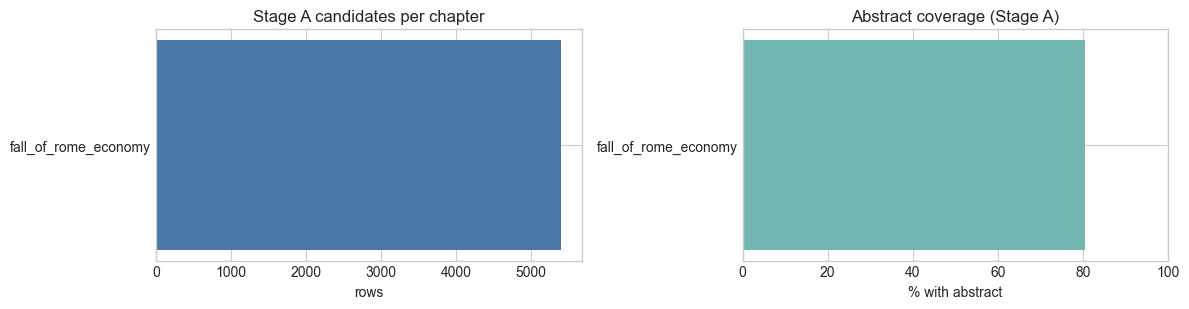

In [11]:
# -----------------------------
# Stage A: API retrieval (OpenAlex + Semantic Scholar)
# -----------------------------

# This cell writes per-chapter StageA corpora to:
#   final_pipeline/stageA/<chapter_id>/<sig>/stageA_combined.csv

import os
import re
import json
import time
import random
import hashlib
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import List, Optional, Dict, Any, Iterable

import requests
import numpy as np
import pandas as pd

OPENALEX_API_KEY = os.getenv("OPENALEX_API_KEY", "").strip()
if not OPENALEX_API_KEY:
    print("Warning: OPENALEX_API_KEY not set; continuing without it (may be slower / more rate limits).")

S2_API_KEY = os.getenv("SEMANTICSCHOLAR_API_KEY", "").strip()
S2_MIN_INTERVAL = 1.0  # seconds (rate limit: 1 rps)
_S2_LAST_TS = 0.0
if S2_API_KEY:
    print("Semantic Scholar API key detected (SEMANTICSCHOLAR_API_KEY). Using authenticated requests (1 req/sec).")
else:
    print("Note: SEMANTICSCHOLAR_API_KEY not set; Semantic Scholar will use long retry/backoff without a key.")

# -----------------------------
# Stage A knobs
# -----------------------------
FETCH_FORCE = False
RUN_OPENALEX = True
RUN_SEMANTIC_SCHOLAR = True

FETCH_MAX_QUERIES_PER_CHAPTER = 15
STAGEA_PRINT_QUERY_PLAN = True  # show blueprint-derived queries per chapter

# Blueprint-driven query expansion (keywords + key_concepts)
QUERY_EXPAND_ENABLED = True
EXTRA_KEY_CONCEPT_QUERIES = 8
EXTRA_KEYWORD_QUERIES = 10
EXTRA_QUERIES_MAX_TOTAL = 18  # cap on extras (after dedupe)
EXTRA_QUERY_APPEND_MAIN = True  # anchor extra terms with main_query

# OpenAlex extra-query caps (keep smaller than base facets)
OA_MAX_WORKS_PER_QUERY_EXTRA = 200

# OpenAlex "authority pull" pass (high-citation results for broad chapter query)
OA_AUTHORITY_PULL_ENABLED = True
OA_AUTHORITY_PULL_MAX_WORKS = 300
OA_AUTHORITY_PULL_SORT = "cited_by_count:desc"

# OpenAlex concept/topic filtering (used for extra queries + authority pull)
OA_CONCEPT_FILTER_ENABLED = True
OA_CONCEPTS_URL = "https://api.openalex.org/concepts"
OA_CONCEPT_TERMS_MAX = 20
OA_CONCEPTS_PER_TERM = 5
OA_CONCEPT_MAX_IDS = 6
OA_CONCEPT_LEVEL_MAX = 2
OA_CONCEPT_MIN_WORKS = 5000
OA_CONCEPT_FILTER_FOR_EXTRA_QUERIES = True
OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL = True

# OpenAlex
OA_BASE_URL = "https://api.openalex.org/works"
OA_PER_PAGE = 100
OA_MAX_WORKS_PER_QUERY = 500
OA_TIMEOUT_SEC = 30

# Semantic Scholar
S2_BASE = "https://api.semanticscholar.org/graph/v1"
S2_SEARCH_URL = f"{S2_BASE}/paper/search"
S2_BATCH_URL  = f"{S2_BASE}/paper/batch"

S2_LIMIT = 100
S2_MAX_PAGES_PER_QUERY = 2
S2_FETCH_ABSTRACTS_VIA_BATCH = True
S2_BATCH_SIZE = 200
S2_CACHE_ENABLED = True
S2_CACHE_TTL_DAYS = 30
S2_VERBOSE = False

# Robust retries/backoff (important without S2_API_KEY)
S2_TIMEOUT_SEC = 30
S2_REQUEST_MAX_RETRIES = 200
S2_REQUEST_MAX_SECONDS = 3600
S2_BACKOFF_INITIAL_SEC = 2.0
S2_BACKOFF_MAX_SEC = 300.0
S2_BACKOFF_JITTER = 0.25
S2_SUCCESS_SLEEP_SEC = 0.2

# Shared Semantic Scholar cache (re-used across notebooks)
S2_CACHE_DIR = SOURCES_WORKSPACE_DIR / "eval_dataset" / "fetch" / "s2_cache"
S2_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Stage A: fetch OpenAlex + Semantic Scholar per chapter
# and build per-chapter StageA CSVs
# -----------------------------

# Output files:
# - eval_dataset/datasets/<dataset_tag>/fetch/openalex_<chapter_id>.csv
# - eval_dataset/datasets/<dataset_tag>/fetch/semantic_scholar_<chapter_id>.csv
# - eval_dataset/datasets/<dataset_tag>/stageA/stageA_combined_oa_s2_<chapter_id>.csv
# - eval_dataset/datasets/<dataset_tag>/stageA/stageA_all_chapters.csv

def dedupe_preserve_order(items: List[str]) -> List[str]:
    seen = set()
    out = []
    for x in items:
        x = str(x).strip()
        if not x:
            continue
        k = x.lower()
        if k in seen:
            continue
        seen.add(k)
        out.append(x)
    return out

def query_list_for_chapter(bp) -> List[str]:
    # Accept both dict blueprints and ChapterBlueprint objects
    if hasattr(bp, "main_query"):
        main = bp.main_query
        facets = list(bp.facet_queries or [])
    else:
        main = (bp.get("main_query", "") if isinstance(bp, dict) else "")
        facets = list((bp.get("facet_queries") or []) if isinstance(bp, dict) else [])
    qs = [main] + facets
    qs = dedupe_preserve_order(qs)
    return qs[:FETCH_MAX_QUERIES_PER_CHAPTER]


def expanded_query_list_for_chapter(bp) -> List[str]:
    """Additional queries derived from blueprint keywords + key_concepts.

    These are *extra* acquisition queries meant to improve recall. We keep them capped
    and (optionally) anchored to the main query to reduce topic drift.
    """

    if not bool(QUERY_EXPAND_ENABLED):
        return []

    if hasattr(bp, "main_query"):
        main = str(bp.main_query or "").strip()
        key_concepts = list(bp.key_concepts or [])
        keywords = list(bp.keywords or [])
    else:
        main = str((bp.get("main_query", "") if isinstance(bp, dict) else "") or "").strip()
        key_concepts = list((bp.get("key_concepts") or []) if isinstance(bp, dict) else [])
        keywords = list((bp.get("keywords") or []) if isinstance(bp, dict) else [])

    terms: List[str] = []
    terms.extend(key_concepts[: int(EXTRA_KEY_CONCEPT_QUERIES)])
    terms.extend(keywords[: int(EXTRA_KEYWORD_QUERIES)])
    terms = dedupe_preserve_order(terms)

    out: List[str] = []
    for t in terms:
        t2 = str(t).strip()
        if not t2:
            continue
        if main and bool(EXTRA_QUERY_APPEND_MAIN):
            out.append(f"{t2} {main}")
        else:
            out.append(t2)

    out = dedupe_preserve_order(out)
    return out[: int(EXTRA_QUERIES_MAX_TOTAL)]


def openalex_concept_terms_for_chapter(bp) -> List[str]:
    """Terms we will map to OpenAlex concept IDs."""

    if hasattr(bp, "main_query"):
        main = str(bp.main_query or "").strip()
        key_concepts = list(bp.key_concepts or [])
        keywords = list(bp.keywords or [])
    else:
        main = str((bp.get("main_query", "") if isinstance(bp, dict) else "") or "").strip()
        key_concepts = list((bp.get("key_concepts") or []) if isinstance(bp, dict) else [])
        keywords = list((bp.get("keywords") or []) if isinstance(bp, dict) else [])

    terms: List[str] = []
    if main:
        terms.append(main)
    terms.extend(key_concepts)
    terms.extend(keywords)
    terms = dedupe_preserve_order(terms)
    return terms[: int(OA_CONCEPT_TERMS_MAX)]


# ----------------------------
# OpenAlex
# ----------------------------

def abstract_from_inverted_index(inv: Optional[Dict[str, List[int]]]) -> Optional[str]:
    if not inv:
        return None

    pairs: List[tuple[int, str]] = []
    for word, positions in inv.items():
        if not positions:
            continue
        for p in positions:
            if isinstance(p, int):
                pairs.append((p, word))

    if not pairs:
        return None

    pairs.sort(key=lambda x: x[0])
    max_pos = pairs[-1][0]
    words = [""] * (max_pos + 1)
    for pos, w in pairs:
        if 0 <= pos <= max_pos:
            words[pos] = w

    text = " ".join(w for w in words if w).strip()
    return text or None

def venue_from_primary_location(work: Dict[str, Any]) -> Optional[str]:
    pl = work.get("primary_location") or {}
    src = pl.get("source") or {}
    return src.get("display_name")

def first_n_authors(work: Dict[str, Any], n: int = 6) -> str:
    authors = []
    for a in (work.get("authorships") or [])[:n]:
        name = ((a.get("author") or {}).get("display_name"))
        if name:
            authors.append(name)
    return "; ".join(authors)

def oa_get(params: Dict[str, Any], max_retries: int = 6) -> dict:
    backoff = 1.0
    for attempt in range(1, max_retries + 1):
        r = requests.get(OA_BASE_URL, params=params, timeout=OA_TIMEOUT_SEC)
        if r.status_code in (429, 500, 502, 503, 504):
            if attempt == max_retries:
                raise RuntimeError(f"OpenAlex error {r.status_code} | URL: {r.url} | Body: {r.text[:400]}")
            time.sleep(backoff)
            backoff *= 2
            continue
        if r.status_code >= 400:
            raise RuntimeError(f"OpenAlex error {r.status_code} | URL: {r.url} | Body: {r.text[:400]}")
        return r.json()
    raise RuntimeError("OpenAlex retry loop exhausted")

def oa_get_url(url: str, params: Dict[str, Any], max_retries: int = 6) -> dict:
    """OpenAlex request helper for endpoints other than /works."""

    backoff = 1.0
    for attempt in range(1, max_retries + 1):
        r = requests.get(url, params=params, timeout=OA_TIMEOUT_SEC)
        if r.status_code in (429, 500, 502, 503, 504):
            if attempt == max_retries:
                raise RuntimeError(f"OpenAlex error {r.status_code} | URL: {r.url} | Body: {r.text[:400]}")
            time.sleep(backoff)
            backoff *= 2
            continue
        if r.status_code >= 400:
            raise RuntimeError(f"OpenAlex error {r.status_code} | URL: {r.url} | Body: {r.text[:400]}")
        return r.json()
    raise RuntimeError("OpenAlex retry loop exhausted")


def _oa_id_short(x: Any) -> Optional[str]:
    s = str(x or "").strip()
    if not s:
        return None
    return s.rsplit("/", 1)[-1]


def openalex_concept_ids_from_terms(terms: List[str]) -> List[str]:
    """Map blueprint terms -> a small set of OpenAlex concept IDs.

    We prefer broader concepts (low level) with enough works to avoid over-filtering.
    """

    if not bool(OA_CONCEPT_FILTER_ENABLED):
        return []

    out: List[str] = []
    for term in (terms or []):
        t = str(term or "").strip()
        if not t:
            continue

        params: Dict[str, Any] = {
            "search": t,
            "per-page": int(OA_CONCEPTS_PER_TERM),
            "select": "id,display_name,level,works_count",
        }
        if OPENALEX_API_KEY:
            params["api_key"] = OPENALEX_API_KEY

        try:
            data = oa_get_url(OA_CONCEPTS_URL, params=params)
        except Exception as e:
            print(f"[OpenAlex:concepts] warning: concept lookup failed for term={t!r}: {e}")
            continue

        for c in (data.get("results") or []):
            lvl = int(c.get("level") or 99)
            wc = int(c.get("works_count") or 0)
            if lvl > int(OA_CONCEPT_LEVEL_MAX):
                continue
            if wc < int(OA_CONCEPT_MIN_WORKS):
                continue
            cid = _oa_id_short(c.get("id"))
            if cid:
                out.append(cid)
                break

        if len(out) >= int(OA_CONCEPT_MAX_IDS):
            break

    out = dedupe_preserve_order(out)
    return out[: int(OA_CONCEPT_MAX_IDS)]


def openalex_concept_filter(concept_ids: List[str]) -> Optional[str]:
    ids = [(_oa_id_short(x) or "") for x in (concept_ids or [])]
    ids = [x for x in ids if x]
    if not ids:
        return None
    # OpenAlex supports OR within the same filter key via `|`.
    return "concept.id:" + "|".join(ids)


def fetch_openalex_query(
    q: Optional[str],
    max_works: Optional[int],
    *,
    filter_: Optional[str] = None,
    sort: Optional[str] = None,
) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []
    cursor = "*"
    select = (
        "id,display_name,publication_year,type,doi,cited_by_count,"
        "authorships,primary_location,abstract_inverted_index"
    )

    q_str = str(q or "").strip()
    query_display = q_str if q_str else "__authority_pull__"

    while cursor:
        params: Dict[str, Any] = {
            "per-page": OA_PER_PAGE,
            "cursor": cursor,
            "select": select,
        }
        if q_str:
            params["search"] = q_str
        if filter_:
            params["filter"] = str(filter_)
        if sort:
            params["sort"] = str(sort)
        if OPENALEX_API_KEY:
            params["api_key"] = OPENALEX_API_KEY

        data = oa_get(params)

        for w in data.get("results", []) or []:
            rows.append({
                "query": query_display,
                "title": w.get("display_name"),
                "year": w.get("publication_year"),
                "type": w.get("type"),
                "venue": venue_from_primary_location(w),
                "cited_by": w.get("cited_by_count"),
                "authors(first6)": first_n_authors(w, n=6),
                "doi": w.get("doi"),
                "openalex_id": w.get("id"),
                "abstract": abstract_from_inverted_index(w.get("abstract_inverted_index")),
            })

            if max_works is not None and len(rows) >= int(max_works):
                return rows

        cursor = (data.get("meta") or {}).get("next_cursor")
        if not cursor:
            break

    return rows

def fetch_openalex_for_chapter(chapter_id: str, query_specs: List[Dict[str, Any]]) -> pd.DataFrame:
    """Fetch OpenAlex for a chapter using a small query plan.

    Each query spec may include:
    - q: search string (optional)
    - max_works: per-query cap
    - filter: OpenAlex filter string (optional)
    - sort: OpenAlex sort string (optional)
    - label: debug label
    """

    all_rows: List[Dict[str, Any]] = []
    total = int(len(query_specs or []))

    for qi, spec in enumerate(query_specs or [], start=1):
        q = spec.get("q")
        label = str(spec.get("label") or "").strip()
        max_works = spec.get("max_works", OA_MAX_WORKS_PER_QUERY)
        filter_ = spec.get("filter")
        sort = spec.get("sort")

        q_disp = str(q or "").strip() or "<no-search>"
        lbl = f"{label} " if label else ""
        sort_disp = f" | sort={sort}" if sort else ""
        filt_disp = " | filter=concepts" if (filter_ and str(filter_).startswith("concept.id:")) else (" | filter=..." if filter_ else "")
        print(f"[OpenAlex:{chapter_id}] ({qi}/{total}) {lbl}{q_disp} | max={max_works}{sort_disp}{filt_disp}")

        all_rows.extend(fetch_openalex_query(q, max_works=max_works, filter_=filter_, sort=sort))

    df_oa = pd.DataFrame(all_rows)
    if df_oa.empty:
        return df_oa

    df_oa.insert(0, "chapter_id", chapter_id)
    df_oa = df_oa.drop_duplicates(subset=["chapter_id", "query", "openalex_id"], keep="first").reset_index(drop=True)
    return df_oa

# ----------------------------
# Semantic Scholar
# ----------------------------

# Shared Semantic Scholar cache across dataset versions (avoids repeated API calls)
S2_CACHE_DIR = Path("eval_dataset/fetch/s2_cache")
S2_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _now_utc() -> datetime:
    return datetime.now(timezone.utc)

def _cache_key(method: str, url: str, params: Optional[Dict[str, Any]], body: Optional[Dict[str, Any]]) -> str:
    blob = {"m": method.upper(), "u": url, "p": params or {}, "b": body or {}}
    s = json.dumps(blob, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha1(s).hexdigest()

def s2_cache_get(method: str, url: str, params: Optional[Dict[str, Any]], body: Optional[Dict[str, Any]]) -> Optional[Any]:
    if not S2_CACHE_ENABLED:
        return None
    key = _cache_key(method, url, params, body)
    path = S2_CACHE_DIR / f"{key}.json"
    if not path.exists():
        return None
    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
        created = datetime.fromisoformat(payload["created"])
        if _now_utc() - created > timedelta(days=S2_CACHE_TTL_DAYS):
            return None
        return payload["data"]
    except Exception:
        return None

def s2_cache_set(method: str, url: str, params: Optional[Dict[str, Any]], body: Optional[Dict[str, Any]], data: Any) -> None:
    if not S2_CACHE_ENABLED:
        return
    key = _cache_key(method, url, params, body)
    path = S2_CACHE_DIR / f"{key}.json"
    payload = {"created": _now_utc().isoformat(), "data": data}
    path.write_text(json.dumps(payload), encoding="utf-8")

def _parse_retry_after(resp: requests.Response) -> Optional[float]:
    ra = resp.headers.get("Retry-After")
    if not ra:
        return None
    try:
        return float(ra)
    except ValueError:
        return None

def s2_request(
    session: requests.Session,
    method: str,
    url: str,
    params: Optional[Dict[str, Any]] = None,
    body: Optional[Dict[str, Any]] = None,
    max_retries: Optional[int] = None,
    max_elapsed_seconds: Optional[float] = None,
) -> Any:
    """Semantic Scholar request with caching + long retry/backoff.

    Without an API key, S2 can rate-limit aggressively (429). We therefore:
    - retry for a long time (default up to ~1 hour per request)
    - respect Retry-After when present
    - use exponential backoff + jitter
    - treat network exceptions as retryable
    """
    global _S2_LAST_TS

    cached = s2_cache_get(method, url, params, body)
    if cached is not None:
        return cached

    max_retries = int(max_retries if max_retries is not None else S2_REQUEST_MAX_RETRIES)
    max_elapsed_seconds = float(max_elapsed_seconds if max_elapsed_seconds is not None else S2_REQUEST_MAX_SECONDS)

    start = time.monotonic()
    backoff = float(S2_BACKOFF_INITIAL_SEC)
    last_status: Any = None
    last_err: Optional[str] = None

    attempt = 0
    while True:
        attempt += 1
        # rate limit: 1 request/second
        now = time.time()
        wait = S2_MIN_INTERVAL - (now - _S2_LAST_TS)
        if wait > 0:
            time.sleep(wait)
        _S2_LAST_TS = time.time()

        resp: Optional[requests.Response]
        try:
            resp = session.request(method, url, params=params, json=body, timeout=S2_TIMEOUT_SEC)
            last_status = resp.status_code
            last_err = None
        except Exception as e:
            resp = None
            last_status = "exception"
            last_err = repr(e)

        if resp is not None and resp.status_code == 200:
            try:
                data = resp.json()
            except Exception as e:
                last_status = "json_error"
                last_err = repr(e)
            else:
                s2_cache_set(method, url, params, body, data)
                return data

        ra = None
        if resp is None:
            retryable = True
        elif resp.status_code in (429, 500, 502, 503, 504):
            retryable = True
            ra = _parse_retry_after(resp)
        elif resp.status_code in (408,):
            retryable = True
        else:
            raise RuntimeError(f"S2 error {resp.status_code} | body: {resp.text[:500]}")

        elapsed = time.monotonic() - start
        if attempt >= max_retries or elapsed >= max_elapsed_seconds:
            detail = f"last_status={last_status}"
            if last_err:
                detail += f" last_err={last_err}"
            raise RuntimeError(
                f"S2 retry budget exhausted after {elapsed:.0f}s and {attempt} attempts: {method} {url} ({detail})"
            )

        wait = float(backoff)
        if ra is not None:
            wait = max(wait, float(ra))
        wait = min(float(S2_BACKOFF_MAX_SEC), wait)
        if S2_BACKOFF_JITTER:
            jitter = 1.0 + random.uniform(-float(S2_BACKOFF_JITTER), float(S2_BACKOFF_JITTER))
            wait = max(0.0, wait * jitter)

        # Minimum sleep to avoid hammering the API
        wait = max(1.0, wait)

        remaining = max_elapsed_seconds - elapsed
        wait = min(wait, max(0.0, remaining))

        if S2_VERBOSE:
            print(
                f"[S2] status={last_status} retry in {wait:.1f}s | attempt {attempt}/{max_retries} | elapsed {elapsed:.0f}s"
            )
        time.sleep(wait)
        backoff = min(float(S2_BACKOFF_MAX_SEC), backoff * 2)

def clean_query(q: str) -> str:
    q = q.replace("-", " ")
    q = re.sub(r"\s+", " ", q).strip()
    return q

def chunks(xs: List[str], n: int) -> Iterable[List[str]]:
    for i in range(0, len(xs), n):
        yield xs[i:i+n]

def fetch_s2_for_chapter(chapter_id: str, queries: List[str], out_csv: Optional[Path] = None) -> pd.DataFrame:
    """Fetch Semantic Scholar results with:
    - long retry/backoff (works without API key)
    - incremental CSV checkpointing (never lose progress)
    - resume support via a small progress JSON
    - optional abstract fetching with a resumable abstract cache
    """
    SEARCH_FIELDS = "paperId,title,year,authors,venue,citationCount,externalIds,url"

    DETAIL_FIELDS = "paperId,abstract"

    base_cols = [
        "chapter_id",
        "query",
        "paperId",
        "title",
        "year",
        "venue",
        "citationCount",
        "authors(first6)",
        "doi",
        "s2_url",
    ]
    csv_cols = base_cols + ["abstract"]

    session = requests.Session()
    session.headers.update({"User-Agent": "instantpaper-eval/1.0"})
    if S2_API_KEY:
        session.headers.update({"x-api-key": S2_API_KEY})

    # --- Resume state (progress + seen keys) ---
    progress_path: Optional[Path] = None
    abstracts_cache_path: Optional[Path] = None
    completed_queries: set[str] = set()
    seen: set[tuple[str, str]] = set()

    queries_sha12 = hashlib.sha1(json.dumps(list(queries), ensure_ascii=False).encode("utf-8")).hexdigest()[:12]

    if out_csv is not None:
        out_csv = Path(out_csv)
        out_csv.parent.mkdir(parents=True, exist_ok=True)
        progress_path = out_csv.with_suffix(".progress.json")
        abstracts_cache_path = out_csv.with_suffix(".abstracts.json")

        if out_csv.exists():
            try:
                existing = pd.read_csv(out_csv)
                if "abstract" not in existing.columns:
                    existing["abstract"] = np.nan
                    tmp_csv = out_csv.with_suffix(".tmp")
                    existing.to_csv(tmp_csv, index=False, encoding="utf-8")
                    tmp_csv.replace(out_csv)
                for q0, pid0 in zip(existing.get("query", []), existing.get("paperId", [])):
                    if pd.isna(q0) or pd.isna(pid0):
                        continue
                    seen.add((str(q0), str(pid0)))
            except Exception:
                # If the file is corrupted/unreadable, we still keep appending new rows.
                pass

        if progress_path.exists():
            try:
                payload = json.loads(progress_path.read_text(encoding="utf-8"))
                if payload.get("queries_sha1_12") == queries_sha12:
                    completed_queries = set(payload.get("completed_queries", []) or [])
            except Exception:
                pass

    def save_progress() -> None:
        if progress_path is None:
            return
        payload = {
            "chapter_id": chapter_id,
            "queries_sha1_12": queries_sha12,
            "completed_queries": sorted(completed_queries),
            "n_completed": int(len(completed_queries)),
            "n_total": int(len(queries)),
            "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        }
        progress_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")

    def append_rows(rows_new: List[Dict[str, Any]]) -> None:
        if not rows_new:
            return
        if out_csv is None:
            rows.extend(rows_new)
            return
        df_new = pd.DataFrame(rows_new)
        for c in csv_cols:
            if c not in df_new.columns:
                df_new[c] = np.nan
        df_new = df_new[csv_cols]
        header = (not out_csv.exists()) or (out_csv.stat().st_size == 0)
        df_new.to_csv(out_csv, mode="a", index=False, header=header, encoding="utf-8")

    # If we are not writing to disk, keep rows in memory.
    rows: List[Dict[str, Any]] = []

    # --- Search loop (incremental checkpointing) ---
    for qi, q in enumerate(queries, start=1):
        if q in completed_queries:
            continue

        q2 = clean_query(q)
        print(f"[S2:{chapter_id}] ({qi}/{len(queries)}) {q2}")

        offset = 0
        for _page in range(1, S2_MAX_PAGES_PER_QUERY + 1):
            params = {
                "query": q2,
                "fields": SEARCH_FIELDS,
                "limit": S2_LIMIT,
                "offset": offset,
            }
            data = s2_request(session, "GET", S2_SEARCH_URL, params=params, body=None)
            time.sleep(S2_SUCCESS_SLEEP_SEC)

            papers = data.get("data", []) or []

            batch_rows: List[Dict[str, Any]] = []
            for p in papers:
                pid = p.get("paperId")
                if not pid:
                    continue
                key = (str(q), str(pid))
                if key in seen:
                    continue
                seen.add(key)

                authors = [a.get("name") for a in (p.get("authors") or [])[:6] if a.get("name")]
                ext = p.get("externalIds") or {}
                batch_rows.append(
                    {
                        "chapter_id": chapter_id,
                        "query": q,
                        "paperId": pid,
                        "title": p.get("title"),
                        "year": p.get("year"),
                        "venue": p.get("venue"),
                        "citationCount": p.get("citationCount"),
                        "authors(first6)": "; ".join(authors),
                        "doi": ext.get("DOI"),
                        "s2_url": p.get("url"),
                    }
                )

            append_rows(batch_rows)

            if len(papers) < S2_LIMIT:
                break
            offset += S2_LIMIT

        completed_queries.add(q)
        save_progress()

    # Load current results
    if out_csv is not None and out_csv.exists():
        df_s2 = pd.read_csv(out_csv)
    else:
        df_s2 = pd.DataFrame(rows)

    if df_s2.empty:
        return df_s2

    df_s2 = df_s2.drop_duplicates(subset=["chapter_id", "query", "paperId"]).reset_index(drop=True)

    # --- Abstract fetching (resumable) ---
    if S2_FETCH_ABSTRACTS_VIA_BATCH:
        abstracts: Dict[str, Optional[str]] = {}

        # Load existing abstract cache
        if abstracts_cache_path is not None and abstracts_cache_path.exists():
            try:
                abstracts.update(json.loads(abstracts_cache_path.read_text(encoding="utf-8")))
            except Exception:
                pass

        # Also trust already-present abstracts in CSV
        if "abstract" in df_s2.columns:
            for pid, abs_ in zip(df_s2.get("paperId", []), df_s2.get("abstract", [])):
                if pd.isna(pid) or pd.isna(abs_):
                    continue
                abstracts[str(pid)] = str(abs_)

        unique_ids = [str(pid) for pid in df_s2["paperId"].dropna().unique().tolist() if pid]
        missing_ids = [pid for pid in unique_ids if pid not in abstracts]

        if missing_ids:
            print(f"[S2:{chapter_id}] fetching abstracts via batch | missing={len(missing_ids)}/{len(unique_ids)}")

        for ids in chunks(missing_ids, S2_BATCH_SIZE):
            params = {"fields": DETAIL_FIELDS}
            body = {"ids": ids}
            batch = s2_request(session, "POST", S2_BATCH_URL, params=params, body=body)
            time.sleep(S2_SUCCESS_SLEEP_SEC)

            if isinstance(batch, list):
                it = batch
            else:
                it = (batch.get("data", []) or [])

            for p in it:
                pid = p.get("paperId")
                if pid:
                    abstracts[str(pid)] = p.get("abstract")

            # Persist abstract cache after each chunk (checkpoint)
            if abstracts_cache_path is not None:
                tmp = abstracts_cache_path.with_suffix(".tmp")
                tmp.write_text(json.dumps(abstracts, ensure_ascii=False), encoding="utf-8")
                tmp.replace(abstracts_cache_path)

        df_s2["abstract"] = df_s2["paperId"].astype(str).map(abstracts)

    # Always persist the latest full CSV (including abstracts if enabled)
    if out_csv is not None:
        tmp_csv = out_csv.with_suffix(".tmp")
        df_s2.to_csv(tmp_csv, index=False, encoding="utf-8")
        tmp_csv.replace(out_csv)

    return df_s2

# ----------------------------
# Stage A merge (OpenAlex + S2) per chapter
# ----------------------------

def standardize_openalex(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()
    d["source"] = "openalex"
    d["source_id"] = d.get("openalex_id")
    d["citation_count"] = d.get("cited_by")
    for col in ["abstract", "doi", "title", "year", "venue", "type", "authors(first6)", "query", "chapter_id", "openalex_id"]:
        if col not in d.columns:
            d[col] = np.nan
    return d[[
        "chapter_id",
        "source", "source_id", "query", "title", "year", "venue", "type",
        "authors(first6)", "doi", "citation_count", "abstract", "openalex_id"
    ]]

def standardize_s2(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()
    d["source"] = "semantic_scholar"
    d["source_id"] = d.get("paperId")
    d["citation_count"] = d.get("citationCount")
    for col in ["abstract", "doi", "title", "year", "venue", "authors(first6)", "query", "paperId", "s2_url", "chapter_id"]:
        if col not in d.columns:
            d[col] = np.nan
    d["type"] = np.nan
    d["openalex_id"] = np.nan
    return d[[
        "chapter_id",
        "source", "source_id", "query", "title", "year", "venue", "type",
        "authors(first6)", "doi", "citation_count", "abstract", "paperId", "s2_url"
    ]]

def normalize_doi(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if not x:
        return None
    x = re.sub(r"^https?://(dx\\.)?doi\\.org/", "", x)
    x = re.sub(r"^doi:\\s*", "", x)
    x = x.strip()
    return x or None

def normalize_title(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if not x:
        return None
    x = re.sub(r"[\\u2010-\\u2015]", "-", x)
    x = re.sub(r"[^a-z0-9\\s]", " ", x)
    x = re.sub(r"\\s+", " ", x).strip()
    return x or None

def longest_text(series):
    vals = [v for v in series if isinstance(v, str) and v.strip()]
    if not vals:
        return None
    return max(vals, key=len)

def most_common_or_longest(series):
    vals = [v for v in series if isinstance(v, str) and v.strip()]
    if not vals:
        return None
    vc = pd.Series(vals).value_counts()
    if len(vc) and vc.iloc[0] >= 2:
        return vc.index[0]
    return max(vals, key=len)

def first_nonnull(series):
    for v in series:
        if pd.notna(v) and v not in ("", None):
            return v
    return None

def within_source_key(df_in: pd.DataFrame) -> pd.Series:
    k = []
    for _, r in df_in.iterrows():
        if r.get("doi_norm"):
            k.append(f"doi:{r['doi_norm']}")
        elif pd.notna(r.get("source_id")):
            k.append(f"id:{r['source']}:{r['source_id']}")
        else:
            y = int(r["year"]) if pd.notna(r.get("year")) else ""
            k.append(f"ty:{r['title_norm']}|{y}")
    return pd.Series(k, index=df_in.index)

def cross_source_merge_key(r: pd.Series) -> str:
    if isinstance(r.get("doi_norm"), str) and r.get("doi_norm"):
        return f"doi:{r['doi_norm']}"
    if pd.notna(r.get("year")):
        return f"ty:{r['title_norm']}|{int(round(float(r['year'])))}"
    return f"t:{r['title_norm']}"

def build_stagea(df_oa_raw: pd.DataFrame, df_s2_raw: pd.DataFrame, chapter_id: str) -> pd.DataFrame:
    oa_std = standardize_openalex(df_oa_raw)
    s2_std = standardize_s2(df_s2_raw)

    combined_raw = pd.concat([oa_std, s2_std], ignore_index=True)
    stageA = combined_raw.copy()

    stageA["doi_norm"] = stageA["doi"].map(normalize_doi)
    stageA["title_norm"] = stageA["title"].map(normalize_title)
    stageA["citation_count"] = pd.to_numeric(stageA["citation_count"], errors="coerce")

    stageA = stageA[stageA["title_norm"].notna()].reset_index(drop=True)
    stageA["within_key"] = within_source_key(stageA)

    agg_map = {
        "chapter_id": lambda s: s.iloc[0],
        "source": lambda s: s.iloc[0],
        "source_id": first_nonnull,
        "title": most_common_or_longest,
        "title_norm": lambda s: s.iloc[0],
        "year": lambda s: pd.to_numeric(s, errors="coerce").dropna().median() if s.notna().any() else np.nan,
        "venue": most_common_or_longest,
        "type": most_common_or_longest,
        "authors(first6)": most_common_or_longest,
        "doi": first_nonnull,
        "doi_norm": first_nonnull,
        "citation_count": lambda s: pd.to_numeric(s, errors="coerce").max(),
        "abstract": longest_text,
        "query": lambda s: "; ".join(sorted(set([q for q in s if isinstance(q, str) and q.strip()]))),
        "openalex_id": first_nonnull,
        "paperId": first_nonnull,
        "s2_url": first_nonnull,
    }

    stageA_dedup = (
        stageA
        .groupby(["source", "within_key"], as_index=False)
        .agg(agg_map)
        .drop(columns=["within_key"])
    )

    stageA_dedup["merge_key"] = stageA_dedup.apply(cross_source_merge_key, axis=1)

    def merge_sources(group: pd.DataFrame) -> dict:
        sources = sorted(set(group["source"].dropna().tolist()))
        source_ids = {src: group.loc[group["source"] == src, "source_id"].dropna().astype(str).unique().tolist() for src in sources}

        return {
            "chapter_id": chapter_id,
            "merge_key": group["merge_key"].iloc[0],
            "sources": "; ".join(sources),
            "source_count": len(sources),
            "source_ids": str(source_ids),
            "title": most_common_or_longest(group["title"]),
            "year": pd.to_numeric(group["year"], errors="coerce").dropna().median() if group["year"].notna().any() else np.nan,
            "venue": most_common_or_longest(group["venue"]),
            "type": most_common_or_longest(group["type"]),
            "authors(first6)": most_common_or_longest(group["authors(first6)"]),
            "doi": first_nonnull(group["doi"]),
            "doi_norm": first_nonnull(group["doi_norm"]),
            "citation_count_max": pd.to_numeric(group["citation_count"], errors="coerce").max(),
            "abstract": longest_text(group["abstract"]),
            "queries": "; ".join(sorted(set(
                q for q in group["query"].dropna().tolist()
                if isinstance(q, str) and q.strip()
            ))),
            "openalex_id": first_nonnull(group.get("openalex_id", pd.Series([], dtype=object))),
            "paperId": first_nonnull(group.get("paperId", pd.Series([], dtype=object))),
            "s2_url": first_nonnull(group.get("s2_url", pd.Series([], dtype=object))),
        }

    merged_records = [merge_sources(g) for _, g in stageA_dedup.groupby("merge_key")]
    df_stageA = pd.DataFrame(merged_records)

    df_stageA["merge_kind"] = df_stageA["merge_key"].str.split(":", n=1).str[0]
    df_stageA["has_abstract"] = df_stageA["abstract"].notna() & (df_stageA["abstract"].astype(str).str.len() > 50)
    df_stageA = df_stageA.sort_values(by="citation_count_max", ascending=False, na_position="last").reset_index(drop=True)

    return df_stageA

# ----------------------------

# -----------------------------
# Run Stage A for all chapters
# -----------------------------

stageA_by_chapter: Dict[str, pd.DataFrame] = {}
stageA_stats: Dict[str, Dict[str, Any]] = {}

for ch in CHAPTERS:
    cid = ch["chapter_id"]
    bp = blueprints[cid]

    base_queries = query_list_for_chapter(bp)
    extra_queries = expanded_query_list_for_chapter(bp)

    # Combined queries (used for S2; OA uses a query plan)
    queries_all = dedupe_preserve_order(list(base_queries) + list(extra_queries))

    # OpenAlex concept filter (used only for extra queries + authority pull)
    bp_dict = bp.model_dump() if hasattr(bp, "model_dump") else (bp if isinstance(bp, dict) else {})
    concept_terms = openalex_concept_terms_for_chapter(bp)

    sig_obj = {
        "base_queries": base_queries,
        "extra_queries": extra_queries,
        "queries_all": queries_all,
        "OA_MAX_WORKS_PER_QUERY": OA_MAX_WORKS_PER_QUERY,
        "OA_MAX_WORKS_PER_QUERY_EXTRA": OA_MAX_WORKS_PER_QUERY_EXTRA,
        "OA_AUTHORITY_PULL_ENABLED": OA_AUTHORITY_PULL_ENABLED,
        "OA_AUTHORITY_PULL_MAX_WORKS": OA_AUTHORITY_PULL_MAX_WORKS,
        "OA_AUTHORITY_PULL_SORT": OA_AUTHORITY_PULL_SORT,
        "OA_CONCEPT_FILTER_ENABLED": OA_CONCEPT_FILTER_ENABLED,
        "OA_CONCEPT_FILTER_FOR_EXTRA_QUERIES": OA_CONCEPT_FILTER_FOR_EXTRA_QUERIES,
        "OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL": OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL,
        "OA_CONCEPT_TERMS": concept_terms,
        "OA_CONCEPT_MAX_IDS": OA_CONCEPT_MAX_IDS,
        "S2_LIMIT": S2_LIMIT,
        "S2_MAX_PAGES_PER_QUERY": S2_MAX_PAGES_PER_QUERY,
    }
    sig = hashlib.sha1(json.dumps(sig_obj, sort_keys=True, ensure_ascii=False).encode("utf-8")).hexdigest()[:12]

    ch_dir = STAGEA_DIR / cid / sig
    ch_dir.mkdir(parents=True, exist_ok=True)
    oa_csv = ch_dir / "openalex.csv"
    s2_csv = ch_dir / "semantic_scholar.csv"
    stagea_csv = ch_dir / "stageA_combined.csv"
    concepts_json = ch_dir / "openalex_concepts.json"

    print(
        f"\n=== Stage A for chapter: {cid} | base={len(base_queries)} extra={len(extra_queries)} all={len(queries_all)} | sig={sig} ==="
    )


    if bool(globals().get('STAGEA_PRINT_QUERY_PLAN', True)):
        print_section(f"Stage A query plan [{cid}]")
        print_kv({
            'base_queries': len(base_queries),
            'extra_queries': len(extra_queries),
            'queries_all': len(queries_all),
            'authority_pull': bool(OA_AUTHORITY_PULL_ENABLED),
            'concept_filter': bool(OA_CONCEPT_FILTER_ENABLED),
        })

        if base_queries:
            print("\nBase queries (main + facets):")
            for i, q in enumerate(base_queries, start=1):
                print(f"  {i:02d}. {q}")

        if extra_queries:
            print("\nExtra queries (keywords + key_concepts):")
            for i, q in enumerate(extra_queries, start=1):
                print(f"  {i:02d}. {q}")

        if concept_terms:
            print("\nConcept lookup terms (OpenAlex concepts endpoint):")
            for i, t in enumerate(concept_terms, start=1):
                print(f"  {i:02d}. {t}")

        if bool(OA_AUTHORITY_PULL_ENABLED):
            print("\nOpenAlex authority pull:")
            print_kv({
                'max_works': OA_AUTHORITY_PULL_MAX_WORKS,
                'sort': OA_AUTHORITY_PULL_SORT,
                'concept_filter_for_pull': bool(OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL),
            })

    concept_ids: List[str] = []
    concept_filter: Optional[str] = None

    if bool(OA_CONCEPT_FILTER_ENABLED) and (
        bool(OA_CONCEPT_FILTER_FOR_EXTRA_QUERIES) or bool(OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL)
    ):
        # Cache concept IDs per chapter signature
        if concepts_json.exists() and (not FETCH_FORCE):
            try:
                concept_ids = json.loads(concepts_json.read_text(encoding="utf-8"))
            except Exception:
                concept_ids = []
        if not concept_ids:
            concept_ids = openalex_concept_ids_from_terms(concept_terms)
            try:
                concepts_json.write_text(json.dumps(concept_ids, ensure_ascii=False, indent=2), encoding="utf-8")
            except Exception:
                pass
        concept_filter = openalex_concept_filter(concept_ids)
        if concept_ids:
            print(f"[OpenAlex:{cid}] concept filter ids ({len(concept_ids)}): {concept_ids}")

    # OpenAlex
    if RUN_OPENALEX:
        if oa_csv.exists() and not FETCH_FORCE:
            df_oa = pd.read_csv(oa_csv)
            print(f"[OpenAlex:{cid}] cached rows: {len(df_oa)}")
        else:
            oa_specs: List[Dict[str, Any]] = []

            # Base facet/main queries (full cap, no concept filter to avoid recall collapse)
            for q in base_queries:
                oa_specs.append({"label": "base", "q": q, "max_works": OA_MAX_WORKS_PER_QUERY})

            # Extra keyword/concept queries (smaller cap; optionally concept-filtered)
            for q in extra_queries:
                oa_specs.append(
                    {
                        "label": "extra",
                        "q": q,
                        "max_works": OA_MAX_WORKS_PER_QUERY_EXTRA,
                        "filter": concept_filter if bool(OA_CONCEPT_FILTER_FOR_EXTRA_QUERIES) else None,
                    }
                )

            # Authority pull: top-cited results for the broad main query
            if bool(OA_AUTHORITY_PULL_ENABLED):
                oa_specs.append(
                    {
                        "label": "authority",
                        "q": bp_dict.get("main_query") or (base_queries[0] if base_queries else ""),
                        "max_works": OA_AUTHORITY_PULL_MAX_WORKS,
                        "sort": OA_AUTHORITY_PULL_SORT,
                        "filter": concept_filter if bool(OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL) else None,
                    }
                )

            df_oa = fetch_openalex_for_chapter(cid, oa_specs)
            df_oa.to_csv(oa_csv, index=False, encoding="utf-8")
            print(f"[OpenAlex:{cid}] saved: {oa_csv} | rows={len(df_oa)}")
    else:
        df_oa = pd.DataFrame()

    # Semantic Scholar
    if RUN_SEMANTIC_SCHOLAR:
        # Always call the fetcher so it can resume if the CSV exists but is incomplete.
        df_s2 = fetch_s2_for_chapter(cid, queries_all, out_csv=s2_csv)
        print(f"[S2:{cid}] ready: {s2_csv} | rows={len(df_s2)}")
    else:
        df_s2 = pd.DataFrame()

    if stagea_csv.exists() and not FETCH_FORCE:
        df_stageA = pd.read_csv(stagea_csv)
        print(f"[StageA:{cid}] cached rows: {len(df_stageA)}")
    else:
        df_stageA = build_stagea(df_oa, df_s2, chapter_id=cid)
        df_stageA.to_csv(stagea_csv, index=False, encoding="utf-8")
        print(f"[StageA:{cid}] saved: {stagea_csv} | rows={len(df_stageA)}")

    stageA_stats[cid] = {
        'chapter_id': cid,
        'base_queries': len(base_queries),
        'extra_queries': len(extra_queries),
        'all_queries': len(queries_all),
        'openalex_rows': int(len(df_oa)) if isinstance(df_oa, pd.DataFrame) else 0,
        's2_rows': int(len(df_s2)) if isinstance(df_s2, pd.DataFrame) else 0,
        'stageA_rows': int(len(df_stageA)) if isinstance(df_stageA, pd.DataFrame) else 0,
    }

    stageA_by_chapter[cid] = df_stageA

print_section("Stage A summary")
rows = []
for cid, df0 in stageA_by_chapter.items():
    stats = stageA_stats.get(cid) or {}
    rows.append({
        "chapter_id": cid,
        "base_q": str(stats.get("base_queries","")),
        "extra_q": str(stats.get("extra_queries","")),
        "oa_rows": _fmt_int(stats.get("openalex_rows", "")),
        "s2_rows": _fmt_int(stats.get("s2_rows", "")),
        "stageA_rows": _fmt_int(len(df0)),
        "has_abs": _fmt_pct(float(df0.get("has_abstract", pd.Series([False]*len(df0))).mean()) if len(df0) else 0.0),
    })
print_table(rows, columns=["chapter_id","base_q","extra_q","oa_rows","s2_rows","stageA_rows","has_abs"], max_rows=200)

# Stage A plots (quick debugging)
plt = get_plt()
if plt and bool(PLOTS_ENABLED) and isinstance(stageA_by_chapter, dict) and stageA_by_chapter:
    print_section("Stage A plots")
    try:
        plot_rows = []
        for cid, df0 in stageA_by_chapter.items():
            if df0 is None:
                continue
            df0 = df0.copy()
            has_abs = float(df0.get("has_abstract", pd.Series([False] * len(df0))).mean()) if len(df0) else 0.0
            plot_rows.append({
                "chapter_id": str(cid),
                "stageA_rows": int(len(df0)),
                "has_abs": has_abs,
            })

        pdf = pd.DataFrame(plot_rows)
        if not pdf.empty:
            pdf = pdf.sort_values("stageA_rows", ascending=True)
            if len(pdf) > int(PLOT_MAX_CHAPTERS):
                pdf = pdf.tail(int(PLOT_MAX_CHAPTERS)).copy()

            labels = [short_label(x, 28) for x in pdf["chapter_id"].tolist()]
            h = max(3.2, 0.55 * len(pdf) + 1.6)
            fig, axes = plt.subplots(1, 2, figsize=(12, h))

            axes[0].barh(labels, pdf["stageA_rows"].tolist(), color="#4C78A8")
            axes[0].set_title("Stage A candidates per chapter")
            axes[0].set_xlabel("rows")

            axes[1].barh(labels, [100.0 * x for x in pdf["has_abs"].tolist()], color="#72B7B2")
            axes[1].set_title("Abstract coverage (Stage A)")
            axes[1].set_xlabel("% with abstract")
            axes[1].set_xlim(0, 100)

            plt.tight_layout()
            plt.show()
    except Exception as e:
        print("[plots] Stage A plots skipped:", e)



## Stage C (finalized): scoring weights

Chosen via `sources_test.ipynb` Stage C grid search (`stageC_grid_v1_best`).

**Final weights**
- `w_embed_max = 0.0` (use `score_embed_mean_top3` only)
- `w_embed = 0.7`
- `cite_weight = 0.08`


In [12]:
import numpy as np
import pandas as pd

# Finalized Stage C hyperparams (grid-search winner)
STAGEC_FINAL_RUN = "20260130_184909_7370e7a6e85f"  # reference from eval_dataset/experiments
STAGEC_W_EMBED_MAX = 0.0
STAGEC_W_EMBED = 0.7
STAGEC_CITE_WEIGHT = 0.08


def minmax_by_group(df_in: pd.DataFrame, col: str, group_col: str = "chapter_id") -> pd.Series:
    out = pd.Series(index=df_in.index, dtype=float)
    for _, g in df_in.groupby(group_col):
        x = pd.to_numeric(g[col], errors="coerce").fillna(0).to_numpy(dtype=float)
        mn, mx = float(np.min(x)), float(np.max(x))
        out.loc[g.index] = (x - mn) / (mx - mn + 1e-12)
    return out


def add_stagec_final_scores(df_in: pd.DataFrame) -> pd.DataFrame:
    """Adds `score_stageC_final` based on finalized Stage C weights.

    Required columns:
    - chapter_id
    - score_embed_max
    - score_embed_mean_top3
    - score_tfidf
    - score_cite_norm
    """
    required = [
        "chapter_id",
        "score_embed_max",
        "score_embed_mean_top3",
        "score_tfidf",
        "score_cite_norm",
    ]
    missing = [c for c in required if c not in df_in.columns]
    if missing:
        raise ValueError(f"Missing required columns for Stage C scoring: {missing}")

    df = df_in.copy()

    emb_max = pd.to_numeric(df["score_embed_max"], errors="coerce").fillna(0.0)
    emb_b = pd.to_numeric(df["score_embed_mean_top3"], errors="coerce").fillna(0.0)
    df["_emb_raw"] = float(STAGEC_W_EMBED_MAX) * emb_max + (1.0 - float(STAGEC_W_EMBED_MAX)) * emb_b

    df["_emb_n"] = minmax_by_group(df, "_emb_raw")
    df["_tf_n"] = minmax_by_group(df, "score_tfidf")
    df["_cite_n"] = minmax_by_group(df, "score_cite_norm")

    base = float(STAGEC_W_EMBED) * df["_emb_n"] + (1.0 - float(STAGEC_W_EMBED)) * df["_tf_n"]
    df["score_stageC_final"] = (1.0 - float(STAGEC_CITE_WEIGHT)) * base + float(STAGEC_CITE_WEIGHT) * df["_cite_n"]
    return df


print("Stage C finalized weights:")
print("- STAGEC_W_EMBED_MAX:", STAGEC_W_EMBED_MAX)
print("- STAGEC_W_EMBED:", STAGEC_W_EMBED)
print("- STAGEC_CITE_WEIGHT:", STAGEC_CITE_WEIGHT)


Stage C finalized weights:
- STAGEC_W_EMBED_MAX: 0.0
- STAGEC_W_EMBED: 0.7
- STAGEC_CITE_WEIGHT: 0.08


## Stage C (production): facet-union pool + embeddings + finalized scoring

Build a per-chapter candidate pool, score it, and write it to `final_pipeline/stageC/`.


[fall_of_rome_economy] pool size: 3187 (from StageA 5403)

[fall_of_rome_economy] Top candidates (Stage C):


<benutzerverzeichnis>\AppData\Local\Temp\ipykernel_11776\1619520909.py:168: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_survey_like = title_l.str.contains(SURVEY_LIKE_REGEX, regex=True, na=False)


,score_stageC_final,score_embed_max,score_tfidf,score_cite_norm,title,year,type,facet_best_query,venue,sources,source_count,has_abstract,venue_blocklisted,neg_term_hits,is_survey_like
1184,0.833806,0.554982,0.131907,0.413150,Exploring the Economy of Late Antiquity,2015.0,book,"landholding, agrarian productivity, and rural ...",Cambridge University Press eBooks,openalex,1,True,False,0,False
1957,0.799240,0.515421,0.137176,0.226958,Isolation or Integration? A spatial analytical...,2016.0,article,"landholding, agrarian productivity, and rural ...",eScholarship (California Digital Library),openalex,1,True,False,0,False
2449,0.759678,0.585407,0.059892,0.103310,The Fall of Rome Reconsidered: A Synthesis of ...,1982.0,article,"landholding, agrarian productivity, and rural ...",Social Thought and Research,openalex,1,True,False,0,False
1097,0.755703,0.579857,0.100111,0.481876,Resilience and livestock adaptations to demogr...,2021.0,article,"landholding, agrarian productivity, and rural ...",PLoS ONE,openalex,1,True,False,0,False
2636,0.749378,0.485627,0.130945,0.073307,Late Antiquity: Then and Now,2020.0,book-chapter,"landholding, agrarian productivity, and rural ...",IntechOpen eBooks,openalex,1,True,False,0,False


Saved Stage C combined: final_pipeline\stageC\20260208_182359_stageC_all_pool_scored.csv | rows=3187

Stage C summary
Embedding usage:
embed_model  : text-embedding-3-small
requests     : 0
input_tokens : 0
cost_usd     : $0.0000

Per-chapter diagnostics:
chapter_id           | pool  | blocklisted | no_abs | survey_like | top_score
---------------------+-------+-------------+--------+-------------+----------
fall_of_rome_economy | 3,187 | 0           | 450    | 192         | 0.8338   

Stage C plots


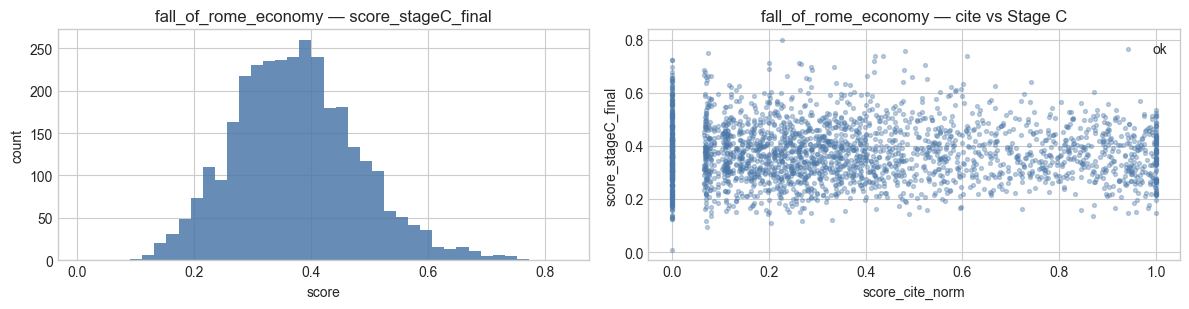

In [13]:
# -----------------------------
# Stage C: pool + scoring (TF-IDF + embeddings) (cached)
# -----------------------------

import json
import hashlib
import re
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Retrieval/scoring hyperparams (same defaults used in eval_dataset_builder.ipynb)
TFIDF_MAX_FEATURES = 200_000
TFIDF_MIN_DF = 2
TFIDF_NGRAM_RANGE = (1, 2)
TOP_PER_QUERY = 400

EMBED_MODEL = "text-embedding-3-small"
MAX_CHARS_PER_EMBED = 3500
EMBED_BATCH_SIZE = 64

# Only used for score_embed_combo (not required for the finalized Stage C score)
W_EMBED_MAX = 0.70
W_EMBED_BREADTH = 0.30

EMBED_CACHE_DIR = SOURCES_WORKSPACE_DIR / ".embed_cache"
EMBED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

STAGEC_FORCE = False

# -----------------------------
# Authority + quality heuristics (Stage C)
# -----------------------------
# Implements (from RESOURCE_RANKING_IMPROVEMENTS.md):
# - A) robust citation normalization
# - B) citation velocity (citations/age)
# - C) multi-source reliability boost
# - D) missing-abstract penalty
# - E) (part) propagate authority later into Stage D relevance (implemented in Stage D cell)
# - F) survey/review/standard/framework-style boosts
# - Additional: blueprint negative_query_terms soft downrank
# - Additional: peer-reviewed type soft preference
# - Additional: suspicious venue downrank via configurable blocklist

CURRENT_YEAR = int(datetime.utcnow().year)

# A/B: citations robust + velocity
CITE_CLIP_Q = 0.95
CITE_VELOCITY_WEIGHT = 0.35
MISSING_YEAR_AGE_DEFAULT = 10  # used when year is missing

# C: multi-source reliability
MULTI_SOURCE_BOOST = 0.02

# D: missing abstract penalty (applied to `score_stageC_final`)
NO_ABSTRACT_PENALTY = 0.10

# Additional: blueprint negatives soft downrank
NEG_TERM_PENALTY_PER_MATCH = 0.06
NEG_TERM_PENALTY_CAP = 0.18

# F: survey/review/standard/framework-style boosts
SURVEY_LIKE_BOOST = 0.02
SURVEY_LIKE_REGEX = r"\b(survey|systematic review|review|taxonomy|reference architecture|standard|framework|state of the art)\b"

# Additional: prefer peer-reviewed types (soft)
PEER_REVIEWED_BOOST = 0.015
PREPRINT_PENALTY = 0.01
PEER_REVIEWED_TYPES = {
    "article",
    "review",
    "book",
    "book-chapter",
}
PREPRINT_TYPES = {
    "preprint",
}

# Additional: suspicious venue downrank via configurable regex blocklist
VENUE_BLOCKLIST_PATH = REPO_ROOT / "config" / "venue_blocklist_regex.txt"
VENUE_BLOCKLIST_PENALTY = 0.15


def robust_minmax(x: pd.Series, *, clip_q: float = 0.95) -> pd.Series:
    """Robust 0..1 scaling by clipping the upper tail.

    - Keeps zeros at 0.
    - Prevents single mega-outliers from compressing everything else.
    """

    v = pd.to_numeric(x, errors="coerce").fillna(0.0).astype(float)
    v = v.clip(lower=0.0)
    if len(v) == 0:
        return v

    if float(v.max()) <= 0.0:
        return v * 0.0

    cap = float(v.quantile(float(clip_q))) if 0.0 < float(clip_q) < 1.0 else float(v.max())
    cap = max(cap, 0.0)
    if cap <= 0.0:
        cap = float(v.max())

    v2 = v.clip(upper=cap)
    mx = float(v2.max())
    return (v2 / mx) if mx > 0.0 else (v2 * 0.0)


def load_regex_blocklist(path: Path) -> list[str]:
    if not path.exists():
        return []
    pats: list[str] = []
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = str(raw).strip()
        if not line or line.startswith("#"):
            continue
        # Validate regex early so we don't explode later.
        try:
            re.compile(line)
        except re.error as e:
            print(f"[StageC] WARNING: invalid venue regex ignored: {line!r} ({e})")
            continue
        pats.append(line)
    return pats


def venue_blocklist_mask(venues: pd.Series, patterns: list[str]) -> pd.Series:
    if not patterns:
        return pd.Series(False, index=venues.index)
    v = venues.fillna("").astype(str)
    m = pd.Series(False, index=venues.index)
    for pat in patterns:
        m = m | v.str.contains(pat, case=False, regex=True, na=False)
    return m


VENUE_BLOCKLIST_PATTERNS = load_regex_blocklist(VENUE_BLOCKLIST_PATH)


def apply_stagec_quality_adjustments(df_in: pd.DataFrame, *, blueprint: dict) -> pd.DataFrame:
    """Post-process Stage C score with low-cost quality/authority heuristics."""

    df = df_in.copy()
    if "score_stageC_final" not in df.columns or len(df) == 0:
        return df

    score = pd.to_numeric(df["score_stageC_final"], errors="coerce").fillna(0.0).astype(float)

    # C) multi-source reliability boost
    sc = pd.to_numeric(df.get("source_count", 1), errors="coerce").fillna(1).astype(int)
    score = score + float(MULTI_SOURCE_BOOST) * (sc >= 2).astype(float)

    # D) missing abstract penalty
    if "has_abstract" in df.columns:
        has_abs = df["has_abstract"].fillna(False).astype(bool)
    else:
        has_abs = df.get("abstract", "").fillna("").astype(str).str.len() > 50
        df["has_abstract"] = has_abs
    score = score * np.where(has_abs.to_numpy(dtype=bool), 1.0, 1.0 - float(NO_ABSTRACT_PENALTY))

    # F) survey/review/standard/framework-style boost
    title_l = df.get("title", "").fillna("").astype(str).str.lower()
    is_survey_like = title_l.str.contains(SURVEY_LIKE_REGEX, regex=True, na=False)
    df["is_survey_like"] = is_survey_like
    score = score + float(SURVEY_LIKE_BOOST) * is_survey_like.astype(float)

    # Additional: peer-reviewed type soft preference
    type_l = df.get("type", "").fillna("").astype(str).str.lower()
    is_peer = type_l.isin(PEER_REVIEWED_TYPES)
    is_preprint = type_l.isin(PREPRINT_TYPES)
    df["is_peer_reviewed_type"] = is_peer
    df["is_preprint_type"] = is_preprint
    score = score + float(PEER_REVIEWED_BOOST) * is_peer.astype(float) - float(PREPRINT_PENALTY) * is_preprint.astype(float)

    # Additional: suspicious venue downrank via blocklist
    venue = df.get("venue", pd.Series([""] * len(df), index=df.index)).fillna("").astype(str)
    venue_bad = venue_blocklist_mask(venue, VENUE_BLOCKLIST_PATTERNS)
    df["venue_blocklisted"] = venue_bad
    score = score * np.where(venue_bad.to_numpy(dtype=bool), 1.0 - float(VENUE_BLOCKLIST_PENALTY), 1.0)

    # Additional: blueprint negatives soft downrank
    neg_terms = [str(x).strip().lower() for x in (blueprint.get("negative_query_terms") or []) if str(x).strip()]
    if neg_terms:
        text_l = df.get("doc_text", "").fillna("").astype(str).str.lower()
        hits = np.zeros(len(df), dtype=int)
        for term in neg_terms:
            hits += text_l.str.contains(term, regex=False, na=False).astype(int).to_numpy(dtype=int)
        df["neg_term_hits"] = hits
        penalty = np.minimum(float(NEG_TERM_PENALTY_CAP), float(NEG_TERM_PENALTY_PER_MATCH) * hits.astype(float))
        score = score * (1.0 - penalty)

    df["score_stageC_final"] = score
    return df


# -----------------------------
# Candidate pool utilities
# -----------------------------

def minmax(x):
    x = np.asarray(x, dtype=float)
    mn, mx = np.nanmin(x), np.nanmax(x)
    return (x - mn) / (mx - mn + 1e-12)

def truncate_text(s: str, max_chars: int) -> str:
    s = "" if s is None else str(s)
    s = s.replace("\n", " ").strip()
    return s[:max_chars]

def build_chapter_query_text(bp: dict) -> str:
    parts = []
    main = bp["main_query"]
    parts.extend([main, main])
    parts.extend(bp.get("facet_queries", []))
    parts.extend(bp.get("keywords", []))
    parts.extend(bp.get("key_concepts", []))
    return " ".join(parts)

def tfidf_scores(query_text: str, vectorizer: TfidfVectorizer, X) -> np.ndarray:
    qv = vectorizer.transform([query_text])
    return cosine_similarity(qv, X).ravel()

def facet_union_pool(bp: dict, df_in: pd.DataFrame, vectorizer: TfidfVectorizer, X, top_per_query: int) -> pd.DataFrame:
    query_texts = [bp["main_query"], bp["main_query"]] + list(bp.get("facet_queries", []))
    pool_keys = set()
    for qt in query_texts:
        qv = vectorizer.transform([qt])
        sims = cosine_similarity(qv, X).ravel()
        top_idx = np.argsort(-sims)[:top_per_query]
        pool_keys.update(df_in.iloc[top_idx]["merge_key"].astype(str).tolist())
    out = df_in[df_in["merge_key"].astype(str).isin(pool_keys)].copy()
    out = out.drop_duplicates(subset=["merge_key"]).reset_index(drop=True)
    return out

def l2_normalize(mat: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(mat, axis=1, keepdims=True) + 1e-12
    return mat / norms

def hash_obj(obj: Any) -> str:
    blob = json.dumps(obj, ensure_ascii=False, sort_keys=True)
    return hashlib.sha1(blob.encode("utf-8")).hexdigest()

def save_npz(path: Path, keys: List[str], mat: np.ndarray):
    np.savez_compressed(path, keys=np.array(keys, dtype=object), embeds=mat.astype(np.float32))

def load_npz(path: Path):
    z = np.load(path, allow_pickle=True)
    return list(z["keys"]), z["embeds"].astype(np.float32)

embed_totals = {"requests": 0, "input_tokens": 0, "cost_usd": 0.0}

def embed_texts(texts: List[str], model: str, batch_size: int, max_retries: int = 6) -> np.ndarray:
    """Embeddings with retries + token/cost tracking."""
    price = MODEL_PRICES_USD_PER_1M.get(model, {"input": 0.0}).get("input", 0.0)
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        backoff = 1.0
        for attempt in range(1, max_retries + 1):
            try:
                resp = client.embeddings.create(model=model, input=batch)
                vecs = [np.array(item.embedding, dtype=np.float32) for item in resp.data]
                all_vecs.extend(vecs)

                usage = getattr(resp, "usage", None)
                tok = int(getattr(usage, "total_tokens", 0) or getattr(usage, "prompt_tokens", 0) or 0)
                embed_totals["requests"] += 1
                embed_totals["input_tokens"] += tok
                embed_totals["cost_usd"] += (tok / 1_000_000) * price
                break
            except Exception:
                if attempt == max_retries:
                    raise
                time.sleep(backoff)
                backoff *= 2
    return np.vstack(all_vecs)

def score_pool_with_embeddings(bp: dict, pool: pd.DataFrame) -> pd.DataFrame:
    pool = pool.copy()
    pool["doc_text_trunc"] = (
        pool["title"].fillna("") + "\n\n" + pool["abstract"].fillna("")
    ).apply(lambda s: truncate_text(s, MAX_CHARS_PER_EMBED))

    keys = pool["merge_key"].astype(str).tolist()

    # Doc embeddings cache
    doc_hash = hash_obj({"model": EMBED_MODEL, "max_chars": MAX_CHARS_PER_EMBED, "keys": keys})[:16]
    doc_npz = EMBED_CACHE_DIR / f"eval_doc_embeds_{EMBED_MODEL}_{doc_hash}.npz"

    # Query embeddings cache
    query_texts = [bp["main_query"], bp["main_query"]] + list(bp.get("facet_queries", []))
    q_hash = hash_obj({"model": EMBED_MODEL, "queries": query_texts})[:16]
    q_json = EMBED_CACHE_DIR / f"eval_query_embeds_{EMBED_MODEL}_{q_hash}.json"

    # Docs
    if doc_npz.exists():
        cached_keys, doc_embeds = load_npz(doc_npz)
        if cached_keys != keys:
            doc_embeds = embed_texts(pool["doc_text_trunc"].tolist(), model=EMBED_MODEL, batch_size=EMBED_BATCH_SIZE)
            save_npz(doc_npz, keys, doc_embeds)
    else:
        doc_embeds = embed_texts(pool["doc_text_trunc"].tolist(), model=EMBED_MODEL, batch_size=EMBED_BATCH_SIZE)
        save_npz(doc_npz, keys, doc_embeds)

    # Queries
    if q_json.exists():
        q_cached = json.loads(q_json.read_text(encoding="utf-8"))
        query_embeds = np.array(q_cached["embeddings"], dtype=np.float32)
    else:
        query_embeds = embed_texts(query_texts, model=EMBED_MODEL, batch_size=EMBED_BATCH_SIZE)
        q_json.write_text(
            json.dumps({"model": EMBED_MODEL, "query_texts": query_texts, "embeddings": query_embeds.tolist()}, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )

    docN = l2_normalize(doc_embeds)
    qN = l2_normalize(query_embeds)
    S = docN @ qN.T

    pool["score_embed_max"] = S.max(axis=1)
    pool["score_embed_mean_top3"] = np.sort(S, axis=1)[:, -3:].mean(axis=1)
    pool["score_embed_norm"] = minmax(pool["score_embed_max"].values)
    pool["score_embed_mean_top3_norm"] = minmax(pool["score_embed_mean_top3"].values)
    pool["score_embed_combo"] = W_EMBED_MAX * pool["score_embed_norm"] + W_EMBED_BREADTH * pool["score_embed_mean_top3_norm"]

    # Facet assignment (exclude the two main-query columns)
    facets = list(bp.get("facet_queries", []))
    if facets:
        facet_S = S[:, 2:2+len(facets)]
        facet_best_i = facet_S.argmax(axis=1).astype(int)
        pool["facet_best_i"] = facet_best_i
        pool["facet_best_query"] = [facets[i] for i in facet_best_i]
    else:
        pool["facet_best_i"] = -1
        pool["facet_best_query"] = ""

    return pool

# -----------------------------
# Build Stage C pool per chapter
# -----------------------------

stageC_by_chapter: Dict[str, pd.DataFrame] = {}
stageC_frames = []

def _load_latest_stagea_csv(chapter_id: str) -> pd.DataFrame:
    ch_dir = STAGEA_DIR / chapter_id
    if not ch_dir.exists():
        raise FileNotFoundError(f"No StageA dir for {chapter_id}: {ch_dir}")
    cands = sorted(ch_dir.glob('*/stageA_combined.csv'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not cands:
        raise FileNotFoundError(f"No stageA_combined.csv found under {ch_dir}")
    return pd.read_csv(cands[0])

for ch in CHAPTERS:
    cid = ch['chapter_id']
    bp_obj = blueprints[cid]
    bp = bp_obj.model_dump()

    # Load StageA corpus
    if 'stageA_by_chapter' in globals() and isinstance(stageA_by_chapter, dict) and cid in stageA_by_chapter:
        df = stageA_by_chapter[cid].copy()
    else:
        df = _load_latest_stagea_csv(cid)

    if df.empty:
        print(f"[{cid}] StageA empty; skipping")
        continue

    # Ensure required columns
    for c_req in ['merge_key', 'title', 'abstract']:
        if c_req not in df.columns:
            raise RuntimeError(f"[{cid}] StageA missing required column: {c_req}")

    df = df.copy()
    df['title'] = df['title'].fillna('')
    df['abstract'] = df['abstract'].fillna('')
    df['doc_text'] = (df['title'].astype(str) + '\n\n' + df['abstract'].astype(str)).str.strip()

    # Citation normalization (robust + velocity) (A/B)
    cites = pd.to_numeric(df.get('citation_count_max', 0), errors='coerce').fillna(0).clip(lower=0)
    df['score_cite_log'] = np.log1p(cites)

    df['score_cite_robust'] = robust_minmax(df['score_cite_log'], clip_q=CITE_CLIP_Q)

    years = pd.to_numeric(df.get('year', np.nan), errors='coerce')
    age = (float(CURRENT_YEAR) - years + 1.0).clip(lower=1.0)
    age = age.fillna(float(MISSING_YEAR_AGE_DEFAULT))
    cites_per_year = cites / age
    df['score_cite_velocity'] = robust_minmax(np.log1p(cites_per_year), clip_q=CITE_CLIP_Q)

    df['score_cite_norm'] = (1.0 - float(CITE_VELOCITY_WEIGHT)) * df['score_cite_robust'] + float(CITE_VELOCITY_WEIGHT) * df['score_cite_velocity']

    # Fit TF-IDF per chapter
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=TFIDF_NGRAM_RANGE,
        max_features=TFIDF_MAX_FEATURES,
        min_df=TFIDF_MIN_DF,
    )
    X = vectorizer.fit_transform(df['doc_text'])

    chapter_query_text = build_chapter_query_text(bp)
    df['score_tfidf'] = tfidf_scores(chapter_query_text, vectorizer=vectorizer, X=X)

    pool = facet_union_pool(bp, df_in=df, vectorizer=vectorizer, X=X, top_per_query=TOP_PER_QUERY)
    print(f"[{cid}] pool size: {len(pool)} (from StageA {len(df)})")

    pool_scored = score_pool_with_embeddings(bp, pool)
    pool_scored = add_stagec_final_scores(pool_scored)
    pool_scored = apply_stagec_quality_adjustments(pool_scored, blueprint=bp)

    # Pretty preview for debugging
    try:
        top_prev = pool_scored.sort_values('score_stageC_final', ascending=False, kind='mergesort').head(5).copy()
        cols_prev = [
            'score_stageC_final','score_embed_max','score_tfidf','score_cite_norm',
            'title','year','type','facet_best_query','venue','sources','source_count',
            'has_abstract','venue_blocklisted','neg_term_hits','is_survey_like'
        ]
        cols_prev = [c for c in cols_prev if c in top_prev.columns]
        print(f'\n[{cid}] Top candidates (Stage C):')
        display(top_prev[cols_prev])
    except Exception:
        pass

    # Persist
    sig_obj = {
        'chapter_id': cid,
        'main_query': bp.get('main_query',''),
        'facet_queries': bp.get('facet_queries', []),
        'TOP_PER_QUERY': TOP_PER_QUERY,
        'EMBED_MODEL': EMBED_MODEL,
        'MAX_CHARS_PER_EMBED': MAX_CHARS_PER_EMBED,
        'TFIDF_MAX_FEATURES': TFIDF_MAX_FEATURES,
        'TFIDF_MIN_DF': TFIDF_MIN_DF,
        'TFIDF_NGRAM_RANGE': TFIDF_NGRAM_RANGE,
    }
    sig = hashlib.sha1(json.dumps(sig_obj, sort_keys=True).encode('utf-8')).hexdigest()[:12]
    out_dir = STAGEC_DIR / cid / sig
    out_dir.mkdir(parents=True, exist_ok=True)
    out_csv = out_dir / 'stageC_pool_scored.csv'
    if (not out_csv.exists()) or STAGEC_FORCE:
        pool_scored.to_csv(out_csv, index=False, encoding='utf-8')
    stageC_by_chapter[cid] = pool_scored
    stageC_frames.append(pool_scored)

stageC_all = pd.concat(stageC_frames, axis=0).reset_index(drop=True) if stageC_frames else pd.DataFrame()
stageC_all_path = STAGEC_DIR / f"{RUN_ID}_stageC_all_pool_scored.csv"
if not stageC_all.empty:
    stageC_all.to_csv(stageC_all_path, index=False, encoding='utf-8')
    print(f"Saved Stage C combined: {stageC_all_path} | rows={len(stageC_all)}")


print_section("Stage C summary")
print("Embedding usage:")
print_kv({
    "embed_model": EMBED_MODEL,
    "requests": _fmt_int(embed_totals.get("requests")),
    "input_tokens": _fmt_int(embed_totals.get("input_tokens")),
    "cost_usd": _fmt_usd(embed_totals.get("cost_usd")),
})

rows = []
for cid, pool in stageC_by_chapter.items():
    if pool is None or len(pool) == 0:
        continue
    rows.append({
        "chapter_id": cid,
        "pool": _fmt_int(len(pool)),
        "blocklisted": _fmt_int(int(pool.get("venue_blocklisted", pd.Series([False]*len(pool))).sum())),
        "no_abs": _fmt_int(int((~pool.get("has_abstract", pd.Series([True]*len(pool)))).sum())),
        "survey_like": _fmt_int(int(pool.get("is_survey_like", pd.Series([False]*len(pool))).sum())),
        "top_score": f"{float(pd.to_numeric(pool['score_stageC_final'], errors='coerce').fillna(0).max()):.4f}",
    })
print("\nPer-chapter diagnostics:")
print_table(rows, columns=["chapter_id","pool","blocklisted","no_abs","survey_like","top_score"], max_rows=200)

# Stage C plots (quick debugging)
plt = get_plt()
if plt and bool(PLOTS_ENABLED) and isinstance(stageC_by_chapter, dict) and stageC_by_chapter:
    print_section("Stage C plots")
    try:
        cids = list(stageC_by_chapter.keys())
        if len(cids) > int(PLOT_MAX_CHAPTERS):
            cids = cids[: int(PLOT_MAX_CHAPTERS)]

        n = len(cids)
        fig, axes = plt.subplots(n, 2, figsize=(12, max(3.2, 3.2 * n)), squeeze=False)

        for r, cid in enumerate(cids):
            dfp = stageC_by_chapter[cid]
            if dfp is None or len(dfp) == 0:
                continue

            s = pd.to_numeric(dfp.get("score_stageC_final", 0.0), errors="coerce").fillna(0.0)
            axes[r, 0].hist(s, bins=40, color="#4C78A8", alpha=0.85)
            axes[r, 0].set_title(f"{short_label(cid, 34)} — score_stageC_final")
            axes[r, 0].set_xlabel("score")
            axes[r, 0].set_ylabel("count")

            # Authority vs Stage C score scatter (sampled)
            if len(dfp) > int(PLOT_MAX_POINTS):
                samp = dfp.sample(n=int(PLOT_MAX_POINTS), random_state=42)
            else:
                samp = dfp

            x = pd.to_numeric(samp.get("score_cite_norm", 0.0), errors="coerce").fillna(0.0)
            y = pd.to_numeric(samp.get("score_stageC_final", 0.0), errors="coerce").fillna(0.0)
            bad = samp.get("venue_blocklisted", False)
            bad = bad.fillna(False).astype(bool) if hasattr(bad, "fillna") else pd.Series([False] * len(samp))

            axes[r, 1].scatter(x[~bad], y[~bad], s=8, alpha=0.35, label="ok", color="#4C78A8")
            if bool(bad.any()):
                axes[r, 1].scatter(x[bad], y[bad], s=10, alpha=0.6, label="blocklisted", color="#E45756")

            axes[r, 1].set_title(f"{short_label(cid, 34)} — cite vs Stage C")
            axes[r, 1].set_xlabel("score_cite_norm")
            axes[r, 1].set_ylabel("score_stageC_final")
            axes[r, 1].legend(loc="best")

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("[plots] Stage C plots skipped:", e)



In [14]:
# -----------------------------
# Stage C.3 (finalized): LLM rerank within Stage C top-N
# -----------------------------
#
# Final decision from LOCO testing (2026-01-31):
# - Use the LLM only as a shortlist reranker to avoid full-rewrite errors.
# - Select top-N by `score_stageC_final`, then order that shortlist by LLM score.

import asyncio
import time
import random
from typing import Dict, Tuple, Literal

import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm  # type: ignore
except Exception:  # pragma: no cover
    tqdm = None

STAGEC3_TOPN = 50
STAGEC3_TOPN_MAX = 250  # adaptive expansion ceiling (per chapter)
STAGEC3_TOPN_STEP = 25   # expand in chunks until enough non-excludes
STAGEC3_MIN_NON_EXCLUDE = 20  # ensure Stage D can select 20 without tail fallback

STAGEC3_MODEL = "gpt-5-nano"
STAGEC3_PROMPT_VERSION = "v2"

STAGEC3_ALPHA_LLM = 0.2  # LLM weight in Stage C.3 ordering/signal (alpha=0.2 was best in offline sweeps)

STAGEC3_CONFIDENCE_MIN = 50  # ignore low-confidence LLM judgments

STAGEC3_CONCURRENCY = 8
STAGEC3_MAX_RETRIES = 8
STAGEC3_BACKOFF_INITIAL = 1.0
STAGEC3_BACKOFF_MAX = 30.0
STAGEC3_ABSTRACT_MAX_CHARS = 2000

STAGEC3_FORCE_RERANK = False

STAGEC3_DIR = OUT_DIR / "stageC3_rerank_cache_v1"
STAGEC3_DIR.mkdir(parents=True, exist_ok=True)


class StageC3RerankOut(BaseModel):
    label: Literal["include", "maybe", "exclude"] = Field(...)
    confidence: int = Field(..., ge=0, le=100)
    score: int = Field(..., ge=0, le=100)
    notes: str = Field("", max_length=140)

stagec3_agent = Agent(
    name=f"StageC3 Shortlist Rerank ({STAGEC3_PROMPT_VERSION})",
    model=STAGEC3_MODEL,
    model_settings=ModelSettings(top_p=1.0, verbosity="low"),
    instructions=(
        "You validate whether a paper fits the chapter rubric.\n"
        "Return ONLY the structured output.\n\n"
        "Scoring (score is 0-100, not 0-3):\n"
        "- 90-100: excellent fit (covers multiple MUST_COVER, avoids MUST_AVOID)\n"
        "- 70-89: strong fit\n"
        "- 40-69: partial/tangential fit\n"
        "- 0-39: out of scope / wrong domain / violates MUST_AVOID\n\n"
        "label must match score: include>=70, maybe 40-69, exclude<40.\n"
        "If keywords are used in a different domain/context than the chapter, label exclude and score<=10.\n"
        "If ABSTRACT is missing, be conservative: lower confidence and avoid high scores."
    ),
    output_type=StageC3RerankOut,
)


def _stagec3_rubric_signature(bp: ChapterBlueprint) -> str:
    payload = {
        "scope_statement": bp.scope_statement,
        "must_cover": bp.must_cover,
        "must_avoid": bp.must_avoid,
        "scoring_guidance": bp.scoring_guidance,
        "prompt_version": STAGEC3_PROMPT_VERSION,
        "model": STAGEC3_MODEL,
        "abstract_max_chars": STAGEC3_ABSTRACT_MAX_CHARS,
    }
    return hashlib.sha1(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:8]


def _stagec3_prompt(bp: ChapterBlueprint, title: str, abstract: str) -> str:
    scope = bp.scope_statement
    must_cover = bp.must_cover or []
    must_avoid = bp.must_avoid or []
    guidance = bp.scoring_guidance or ""

    abs_txt = (abstract or "").strip()
    if STAGEC3_ABSTRACT_MAX_CHARS and len(abs_txt) > int(STAGEC3_ABSTRACT_MAX_CHARS):
        abs_txt = abs_txt[: int(STAGEC3_ABSTRACT_MAX_CHARS)]

    lines = []
    lines.append("Score this paper for inclusion in the chapter.")
    lines.append("Return only the schema fields.")
    lines.append("")
    lines.append("SCORING")
    lines.append("- score: integer 0-100 (not 0-3); use the full range")
    lines.append("- label must match score: include>=70, maybe 40-69, exclude<40")
    lines.append("- confidence: 0-100 certainty; use low confidence if ABSTRACT is missing")
    lines.append("- if domain/context mismatches the chapter, label exclude and score<=10")
    lines.append("")
    lines.append("RUBRIC")
    lines.append(f"SCOPE: {scope}")
    if guidance:
        lines.append(f"GUIDANCE: {guidance}")
    if must_cover:
        lines.append("MUST_COVER:")
        for b in must_cover:
            lines.append(f"- {b}")
    if must_avoid:
        lines.append("MUST_AVOID:")
        for b in must_avoid:
            lines.append(f"- {b}")
    lines.append("")
    lines.append("PAPER")
    lines.append(f"TITLE: {(title or '').strip()}")
    if abs_txt:
        lines.append(f"ABSTRACT: {abs_txt}")
    else:
        lines.append("ABSTRACT: (missing)")
    lines.append("")
    return "\n".join(lines)


def _minmax_series(x: pd.Series) -> pd.Series:
    v = pd.to_numeric(x, errors="coerce").fillna(0.0)
    mn, mx = float(v.min()), float(v.max())
    return (v - mn) / (mx - mn + 1e-12)



async def stagec3_rerank_topn(
    df_in: pd.DataFrame,
    blueprints_by_chapter_id: Dict[str, ChapterBlueprint],
    *,
    topn: int = STAGEC3_TOPN,
    topn_max: int = STAGEC3_TOPN_MAX,
    topn_step: int = STAGEC3_TOPN_STEP,
    min_non_exclude: int = STAGEC3_MIN_NON_EXCLUDE,
    id_col: str = "merge_key",
) -> Tuple[pd.DataFrame, dict]:
    """Adds Stage C.3 shortlist rerank scores.

    Scientific intent:
    - We only use the LLM inside a shortlist (top-N by Stage C score).
    - In production, some chapters can have too many `exclude` labels inside top-N.
      If we then run Stage D (diversity selection), it may be forced to pick from the
      unscored tail and output irrelevant, unlabeled results.

    Therefore this function *adaptively expands* the per-chapter shortlist until we have
    at least `min_non_exclude` items labeled {include, maybe} (ignoring excludes), up to
    `topn_max`.

    Required columns in df_in:
    - chapter_id
    - title
    - abstract
    - score_stageC_final

    Returns (df_out, totals).
    """
    required = ["chapter_id", "title", "abstract", "score_stageC_final"]
    missing = [c for c in required if c not in df_in.columns]
    if missing:
        raise ValueError(f"Missing required columns for Stage C.3: {missing}")

    df = df_in.copy()

    print_section("Stage C.3 rerank")
    print_kv({
        "model": STAGEC3_MODEL,
        "topn": int(topn),
        "topn_max": int(topn_max),
        "min_non_exclude": int(min_non_exclude),
        "concurrency": int(STAGEC3_CONCURRENCY),
        "force_rerank": bool(STAGEC3_FORCE_RERANK),
    })

    # Ensure stable id
    if id_col not in df.columns:
        years = df["year"] if "year" in df.columns else pd.Series([""] * len(df), index=df.index)
        df[id_col] = [
            hashlib.sha1(f"{t}|{y}".encode("utf-8")).hexdigest()[:16]
            for t, y in zip(df["title"].fillna("").astype(str), years.fillna("").astype(str))
        ]

    # Output columns
    df["score_llm_rerank_v1"] = np.nan
    df["llm_notes"] = ""
    df["llm_label"] = ""
    df["llm_confidence"] = np.nan

    sem = asyncio.Semaphore(int(STAGEC3_CONCURRENCY))
    t0 = time.time()

    totals = {
        "seconds": 0.0,
        "requests": 0,
        "input_tokens": 0,
        "cached_input_tokens": 0,
        "output_tokens": 0,
        "cost_usd": 0.0,
        "cached_files": 0,
        "topn_used_by_chapter": {},
    }

    async def _run_one(chapter_id: str, doc_id: str, title: str, abstract: str) -> dict:
        bp = blueprints_by_chapter_id[chapter_id]
        sig = _stagec3_rubric_signature(bp)
        cache_dir = STAGEC3_DIR / sig / chapter_id
        cache_dir.mkdir(parents=True, exist_ok=True)
        doc_sig = hashlib.sha1(str(doc_id).encode("utf-8")).hexdigest()[:16]
        cache_path = cache_dir / f"{doc_sig}.json"

        if cache_path.exists() and not STAGEC3_FORCE_RERANK:
            payload = json.loads(cache_path.read_text(encoding="utf-8"))
            payload["_meta"] = payload.get("_meta") or {}
            payload["_meta"]["llm_cached"] = True
            payload["_meta"]["requests"] = 0
            payload["_meta"]["input_tokens"] = 0
            payload["_meta"]["cached_input_tokens"] = 0
            payload["_meta"]["output_tokens"] = 0
            payload["_meta"]["cost_usd"] = 0.0
            return payload

        prompt = _stagec3_prompt(bp, title=title, abstract=abstract)
        last_err = None
        for attempt in range(int(STAGEC3_MAX_RETRIES)):
            try:
                async with sem:
                    res = await Runner.run(stagec3_agent, prompt)
                usage = getattr(getattr(res, "context_wrapper", None), "usage", None)
                meta = cost_from_usage(usage, model=STAGEC3_MODEL) if usage is not None else {
                    "requests": 1,
                    "input_tokens": 0,
                    "cached_input_tokens": 0,
                    "output_tokens": 0,
                    "cost_usd": 0.0,
                }
                out = {
                    "label": str(res.final_output.label),
                    "confidence": int(res.final_output.confidence),
                    "score": int(res.final_output.score),
                    "notes": str(res.final_output.notes or ""),
                    "_meta": {**meta, "llm_cached": False, "rubric_sig": sig, "model": STAGEC3_MODEL},
                }
                cache_path.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding="utf-8")
                return out
            except Exception as e:
                last_err = e
                backoff = min(float(STAGEC3_BACKOFF_MAX), float(STAGEC3_BACKOFF_INITIAL) * (2 ** attempt))
                backoff = backoff * (0.75 + 0.5 * random.random())
                await asyncio.sleep(backoff)

        raise RuntimeError(
            f"Stage C.3 rerank failed after retries for chapter_id={chapter_id} doc_id={doc_id}: {last_err}"
        )

    async def _wrapped(ix: int, chapter_id: str, doc_id: str, title: str, abstract: str) -> Tuple[int, dict]:
        payload = await _run_one(chapter_id, doc_id, title, abstract)
        return ix, payload

    # Ranked candidate indices per chapter (by Stage C score)
    ranked: Dict[str, list[int]] = {}
    desired: Dict[str, int] = {}

    for chapter_id, g in df.groupby("chapter_id"):
        cid = str(chapter_id)
        if cid not in blueprints_by_chapter_id:
            raise KeyError(f"Missing blueprint for chapter_id '{cid}'")

        sort_cols = ["score_stageC_final"]
        asc = [False]
        if id_col in g.columns:
            sort_cols.append(id_col)
            asc.append(True)

        ranked[cid] = g.sort_values(sort_cols, ascending=asc, kind="mergesort").index.to_list()
        desired[cid] = int(min(int(topn), len(ranked[cid])))

    # Iteratively score + expand
    enqueued: set[int] = set()

    def _enqueue_upto(cid: str, n: int) -> list[asyncio.Task]:
        tasks_local: list[asyncio.Task] = []
        for ix in ranked[cid][: int(n)]:
            if ix in enqueued:
                continue
            row = df.loc[ix]
            doc_id = str(row[id_col])
            title0 = str(row.get("title") or "")
            abstract0 = str(row.get("abstract") or "")
            tasks_local.append(asyncio.create_task(_wrapped(ix, cid, doc_id, title0, abstract0)))
            enqueued.add(ix)
        return tasks_local

    # Initial enqueue
    tasks: list[asyncio.Task] = []
    for cid, n in desired.items():
        tasks.extend(_enqueue_upto(cid, n))

    round_i = 0
    while tasks:
        round_i += 1
        print(
            f"[StageC3] Round {round_i}: scoring {len(tasks)} docs | model={STAGEC3_MODEL} | concurrency={STAGEC3_CONCURRENCY}"
        )

        iterator = asyncio.as_completed(tasks)
        pbar = None
        if tqdm is not None:
            pbar = tqdm(iterator, total=len(tasks), desc=f"Stage C.3 rerank ({STAGEC3_MODEL})")
            iterator = pbar

        done = 0
        for fut in iterator:
            ix, payload = await fut
            done += 1

            df.loc[ix, "score_llm_rerank_v1"] = payload.get("score")
            df.loc[ix, "llm_notes"] = payload.get("notes", "")
            df.loc[ix, "llm_label"] = payload.get("label", "")
            df.loc[ix, "llm_confidence"] = payload.get("confidence")

            m = payload.get("_meta") or {}
            totals["requests"] += int(m.get("requests", 0) or 0)
            totals["input_tokens"] += int(m.get("input_tokens", 0) or 0)
            totals["cached_input_tokens"] += int(m.get("cached_input_tokens", 0) or 0)
            totals["output_tokens"] += int(m.get("output_tokens", 0) or 0)
            totals["cost_usd"] += float(m.get("cost_usd", 0.0) or 0.0)
            totals["cached_files"] += int(bool(m.get("llm_cached", False)))

            if pbar is None and (done % 25 == 0 or done == len(tasks)):
                elapsed = float(time.time() - t0)
                print(
                    f"[StageC3] {done}/{len(tasks)} | req={totals['requests']} | cached={totals['cached_files']} | cost=${totals['cost_usd']:.4f} | sec={elapsed:.0f}"
                )

        # Decide whether to expand any chapter
        expanded_any = False
        for cid, n in list(desired.items()):
            idx = ranked[cid][: int(n)]
            labels = df.loc[idx, "llm_label"].fillna("").astype(str)
            non_ex = int((labels.ne("") & ~labels.eq("exclude")).sum())

            # store latest desired
            totals["topn_used_by_chapter"][cid] = int(n)

            if non_ex >= int(min_non_exclude):
                continue

            cap = int(min(int(topn_max), len(ranked[cid])))
            if int(n) >= cap:
                continue

            new_n = int(min(cap, int(n) + int(topn_step)))
            desired[cid] = new_n
            expanded_any = True
            print(
                f"[StageC3] Expanding chapter '{cid}': non_exclude={non_ex} < {min_non_exclude} → topn {n}→{new_n}"
            )

        if not expanded_any:
            break

        # Enqueue only newly added indices
        tasks = []
        for cid, n in desired.items():
            tasks.extend(_enqueue_upto(cid, n))

    totals["seconds"] = float(time.time() - t0)

    # Mark which docs were included in the scored shortlist (per chapter)
    df["_in_topn"] = False
    for cid, n in desired.items():
        df.loc[ranked[cid][: int(n)], "_in_topn"] = True

    # Final Stage C.3 score: only promote items that are non-exclude and pass confidence gating
    df["score_stageC3_topn_final"] = pd.to_numeric(df["score_stageC_final"], errors="coerce").fillna(0.0)
    cite_ok = "score_cite_norm" in df.columns
    if not cite_ok:
        df["score_cite_norm"] = 0.0

    for _, g in df[df["_in_topn"]].groupby("chapter_id"):
        llm_raw = pd.to_numeric(g["score_llm_rerank_v1"], errors="coerce").fillna(0.0)
        labels = df.loc[g.index, "llm_label"].fillna("").astype(str)
        conf = pd.to_numeric(df.loc[g.index, "llm_confidence"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        label_rank = labels.map({"exclude": 0, "maybe": 1, "include": 2}).fillna(0).astype(int).to_numpy(dtype=int)
        label_rank = np.where(conf >= float(STAGEC3_CONFIDENCE_MIN), label_rank, 0)
        llm_raw = llm_raw.where(label_rank > 0, 0.0)
        llm_n = _minmax_series(llm_raw).to_numpy(dtype=float)

        stagec = pd.to_numeric(g["score_stageC_final"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        cite = pd.to_numeric(g["score_cite_norm"], errors="coerce").fillna(0.0).to_numpy(dtype=float)

        top = pd.DataFrame({
            "ix": g.index.to_list(),
            "doc_id": df.loc[g.index, id_col].fillna("").astype(str).to_list(),
            "label_rank": label_rank,
            "llm_n": llm_n,
            "stagec": stagec,
            "cite": cite,
        })
        top = top.sort_values(["label_rank", "llm_n", "stagec", "cite", "doc_id"], ascending=[False, False, False, False, True], kind="mergesort")
        boosted = top[top["label_rank"] > 0].copy()
        for r, ix in enumerate(boosted["ix"].tolist()):
            df.loc[ix, "score_stageC3_topn_final"] = 2.0 - (r * 1e-6)

    if not cite_ok:
        df = df.drop(columns=["score_cite_norm"], errors="ignore")

    print("\nStage C.3 totals:")
    print_kv({
        'seconds': f"{float(totals.get('seconds',0.0)):.1f}",
        'requests': _fmt_int(totals.get('requests')),
        'cached_files': _fmt_int(totals.get('cached_files')),
        'input_tokens': _fmt_int(totals.get('input_tokens')),
        'cached_input_tokens': _fmt_int(totals.get('cached_input_tokens')),
        'output_tokens': _fmt_int(totals.get('output_tokens')),
        'cost_usd': _fmt_usd(totals.get('cost_usd')),
    })

    try:
        rows = [ {'chapter_id': k, 'topn_used': str(v)} for k, v in (totals.get('topn_used_by_chapter') or {}).items() ]
        if rows:
            print("\nTop-N used by chapter:")
            print_table(rows, columns=['chapter_id','topn_used'], max_rows=200)

            # Per-chapter label distribution inside the scored shortlist
            try:
                rows2 = []
                for chapter_id, gg in df[df.get('_in_topn', False)].groupby('chapter_id'):
                    lab = gg.get('llm_label', '').fillna('').astype(str)
                    conf = pd.to_numeric(gg.get('llm_confidence', 0), errors='coerce').fillna(0.0)
                    rows2.append({
                        'chapter_id': str(chapter_id),
                        'topn_used': str((totals.get('topn_used_by_chapter') or {}).get(str(chapter_id), '')),
                        'include': str(int((lab == 'include').sum())),
                        'maybe': str(int((lab == 'maybe').sum())),
                        'exclude': str(int((lab == 'exclude').sum())),
                        'blank': str(int((lab == '').sum())),
                        'avg_conf': f"{float(conf.mean() if len(conf) else 0.0):.1f}",
                    })

                if rows2:
                    print("\nPer-chapter label breakdown (in_topn):")
                    print_table(rows2, columns=['chapter_id','topn_used','include','maybe','exclude','blank','avg_conf'], max_rows=200)
            except Exception:
                pass

    except Exception:
        pass

    return df, totals

print("Stage C.3 finalized params:")
print("- STAGEC3_TOPN:", STAGEC3_TOPN)
print("- STAGEC3_MODEL:", STAGEC3_MODEL)
print("- STAGEC3_PROMPT_VERSION:", STAGEC3_PROMPT_VERSION)


Stage C.3 finalized params:
- STAGEC3_TOPN: 50
- STAGEC3_MODEL: gpt-5-nano
- STAGEC3_PROMPT_VERSION: v2


## Stage D (finalized): MMR TF-IDF selection (diverse top-20)

Purpose: reduce redundancy in the final list while preserving (and in our benchmark improving) relevance.

Final settings (from fully adjudicated benchmark):
- `topm=100`, `lambda=0.6`, `k_select=20`
- pool ordered by `score_stageC3_topn_final`
- selection uses MMR on TF-IDF similarity, then ranks selected items by `score_stageC3_signal_v1`.


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

STAGED_ENABLED = True
STAGED_K_SELECT = 20
STAGED_TOPM = 100
STAGED_LAMBDA = 0.6
STAGED_TFIDF_MAX_FEATURES = 20_000


def _build_text(title: str, abstract: str) -> str:
    t = str(title or "").strip()
    a = str(abstract or "").strip()
    return (t + ". " + a).strip()


def _minmax_series(x: pd.Series) -> pd.Series:
    v = pd.to_numeric(x, errors="coerce").fillna(0.0)
    mn, mx = float(v.min()), float(v.max())
    return (v - mn) / (mx - mn + 1e-12)


def add_stagec3_signal_v1(
    df_in: pd.DataFrame,
    *,
    topn: int = STAGEC3_TOPN,
    stagec_col: str = "score_stageC_final",
    llm_col: str = "score_llm_rerank_v1",
    out_col: str = "score_stageC3_signal_v1",
    authority_col: str = "score_cite_norm",
    authority_gamma: float = 0.08,
) -> pd.DataFrame:
    """Adds a relevance signal for Stage D.

    - For items inside Stage C top-N: `1 + minmax(llm_score) + authority_gamma*minmax(authority)` (label/confidence gated)
    - For the tail: `score_stageC_final`
    """
    df = df_in.copy()
    df[out_col] = pd.to_numeric(df[stagec_col], errors="coerce").fillna(0.0)

    for cid, g in df.groupby("chapter_id"):
        if "_in_topn" in g.columns:
            idx = g[g["_in_topn"].fillna(False)].index
            if len(idx) == 0:
                idx = g.sort_values(stagec_col, ascending=False, kind="mergesort").head(int(topn)).index
        else:
            idx = g.sort_values(stagec_col, ascending=False, kind="mergesort").head(int(topn)).index
        llm_raw = pd.to_numeric(df.loc[idx, llm_col], errors="coerce").fillna(0.0)
        gate = pd.Series(True, index=idx)
        if "llm_label" in df.columns:
            labels = df.loc[idx, "llm_label"].fillna("").astype(str)
            gate = gate & ~labels.eq("exclude")
        if "llm_confidence" in df.columns:
            conf = pd.to_numeric(df.loc[idx, "llm_confidence"], errors="coerce").fillna(0.0)
            conf_min = float(globals().get("STAGEC3_CONFIDENCE_MIN", 0) or 0)
            if conf_min > 0:
                gate = gate & (conf >= conf_min)

        valid_idx = idx[gate.to_numpy(dtype=bool)]
        if len(valid_idx):
            llm_n_valid = _minmax_series(llm_raw.loc[valid_idx])
            signal = 1.0 + llm_n_valid
            if float(authority_gamma) and (authority_col in df.columns):
                auth = pd.to_numeric(df.loc[valid_idx, authority_col], errors="coerce").fillna(0.0)
                auth_n = _minmax_series(auth)
                signal = signal + float(authority_gamma) * auth_n
            df.loc[valid_idx, out_col] = signal
    return df


def mmr_select(relevance: np.ndarray, sim: np.ndarray, k: int, lam: float) -> List[int]:
    n = int(len(relevance))
    if n == 0:
        return []
    k = int(min(k, n))

    chosen: List[int] = []
    remaining = list(range(n))

    first = int(np.argmax(relevance))
    chosen.append(first)
    remaining.remove(first)

    eps = 1e-12
    while len(chosen) < k and remaining:
        best_i = None
        best_score = -1e18
        for i in remaining:
            max_sim = max(float(sim[i, j]) for j in chosen) if chosen else 0.0
            s = float(lam) * float(relevance[i]) - (1.0 - float(lam)) * float(max_sim)
            if (s > best_score + eps) or (abs(s - best_score) <= eps and (best_i is None or int(i) < int(best_i))):
                best_score = s
                best_i = int(i)
        chosen.append(int(best_i))
        remaining.remove(int(best_i))
    return chosen


def add_stageD_mmr_tfidf_v2(
    df_in: pd.DataFrame,
    *,
    baseline_col: str = "score_stageC3_topn_final",
    relevance_col: str = "score_stageC3_signal_v1",
    title_col: str = "title",
    abstract_col: str = "abstract",
    id_col: str = "merge_key",
    topm: int = STAGED_TOPM,
    k_select: int = STAGED_K_SELECT,
    lam: float = STAGED_LAMBDA,
    out_col: str = "score_stageD_final",
) -> pd.DataFrame:
    """Stage D: select a diverse top-K using TF-IDF MMR.

    Output behavior:
    - Selected docs get scores `3.0 - r*1e-6` (strict ordering).
    - All other docs keep `baseline_col` scores.
    """
    df = df_in.copy()
    required = ["chapter_id", baseline_col, relevance_col, title_col, abstract_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for Stage D: {missing}")

    df[out_col] = pd.to_numeric(df[baseline_col], errors="coerce").fillna(0.0)

    for cid, g in df.groupby("chapter_id"):
        g_sorted = g.sort_values([baseline_col, id_col], ascending=[False, True], kind="mergesort")
        pool = g_sorted.copy()
        # Prefer selecting only from the docs that Stage C.3 actually scored (avoids unlabeled tail docs).
        if "_in_topn" in pool.columns:
            pool = pool[pool["_in_topn"].fillna(False)].copy()
        if 'llm_label' in pool.columns:
            pool = pool[pool['llm_label'].fillna('').astype(str).ne('')].copy()
            pool = pool[~pool['llm_label'].fillna('').astype(str).eq('exclude')].copy()
        if int(topm) > 0 and len(pool) > int(topm):
            pool = pool.sort_values([baseline_col, id_col], ascending=[False, True], kind="mergesort").head(int(topm)).copy()
        if len(pool) == 0:
            print(f"[StageD] Warning: empty pool for {cid}; skipping Stage D for this chapter.")
            continue
        if len(pool) < int(k_select):
            print(f"[StageD] Warning: pool<{k_select} for {cid}: pool={len(pool)}. Consider increasing Stage C.3 topn/topn_max.")
        texts = [_build_text(t, a) for t, a in zip(pool[title_col].fillna(""), pool[abstract_col].fillna(""))]
        tfidf = TfidfVectorizer(max_features=int(STAGED_TFIDF_MAX_FEATURES))
        X = tfidf.fit_transform(texts)
        S = cosine_similarity(X)

        rel = pd.to_numeric(pool[relevance_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        chosen_local = mmr_select(rel, S, k=int(k_select), lam=float(lam))
        chosen_idx = pool.iloc[chosen_local].index.tolist()

        chosen_sorted = (
            pool.loc[chosen_idx]
            .sort_values([relevance_col, baseline_col, id_col], ascending=[False, False, True], kind="mergesort")
            .index.tolist()
        )
        for r, ix in enumerate(chosen_sorted):
            df.loc[ix, out_col] = 3.0 - (r * 1e-6)

    return df


print("Stage D finalized params:")
print("- enabled:", STAGED_ENABLED)
print("- k_select:", STAGED_K_SELECT)
print("- topm:", STAGED_TOPM)
print("- lambda:", STAGED_LAMBDA)


print_section("Stage D config")
print_kv({
    "enabled": STAGED_ENABLED,
    "k_select": STAGED_K_SELECT,
    "topm": STAGED_TOPM,
    "lambda": STAGED_LAMBDA,
    "tfidf_max_features": STAGED_TFIDF_MAX_FEATURES,
})


Stage D finalized params:
- enabled: True
- k_select: 20
- topm: 100
- lambda: 0.6

Stage D config
enabled            : True
k_select           : 20
topm               : 100
lambda             : 0.6
tfidf_max_features : 20000


## Final run (production)

Runs Stage C.3 (LLM rerank within top‑N) and Stage D (MMR TF‑IDF) and writes outputs to `final_pipeline/results/`.
After you `Run All`, paste the printed JSON summary back here.


Using in-memory stageC_all | rows= 3187

Stage C.3 rerank
model           : gpt-5-nano
topn            : 50
topn_max        : 250
min_non_exclude : 20
concurrency     : 8
force_rerank    : False
[StageC3] Round 1: scoring 50 docs | model=gpt-5-nano | concurrency=8


Stage C.3 rerank (gpt-5-nano):   0%|          | 0/50 [00:00<?, ?it/s]

[StageC3] Expanding chapter 'fall_of_rome_economy': non_exclude=17 < 20 → topn 50→75
[StageC3] Round 2: scoring 25 docs | model=gpt-5-nano | concurrency=8


Stage C.3 rerank (gpt-5-nano):   0%|          | 0/25 [00:00<?, ?it/s]


Stage C.3 totals:
seconds             : 0.3
requests            : 0
cached_files        : 75
input_tokens        : 0
cached_input_tokens : 0
output_tokens       : 0
cost_usd            : $0.0000

Top-N used by chapter:
chapter_id           | topn_used
---------------------+----------
fall_of_rome_economy | 75       

Per-chapter label breakdown (in_topn):
chapter_id           | topn_used | include | maybe | exclude | blank | avg_conf
---------------------+-----------+---------+-------+---------+-------+---------
fall_of_rome_economy | 75        | 21      | 6     | 48      | 0     | 68.8    
Saved full scored CSV: final_pipeline\results\20260208_182359_full_scored.csv

OpenAI cost summary
stage             | requests | in_tok | cached_in | out_tok | cost_usd
------------------+----------+--------+-----------+---------+---------
stageB_blueprints | 0        | 0      | 0         | 0       | $0.0000 
embeddings        | 0        | 0      |           |         | $0.0000 
stageC3_rerank    

,chapter_id,title,year,venue,doi_norm,sources,queries,query_origin,query_hit_count,query_hits_base,query_hits_extra,score_stageC_final,score_llm_rerank_v1,llm_label,llm_confidence,llm_notes,score_stageD_final,merge_key
649,fall_of_rome_economy,Resetting the Urban Network: 117-2012,2016.0,The Economic Journal,https://doi.org/10.1111/ecoj.12424,openalex,late western Roman economy evidence links poli...,base,2,2,0,0.627365,88.0,include,85.0,Strong fit: analyzes economic mechanisms and s...,3.000000,doi:https://doi.org/10.1111/ecoj.12424
1029,fall_of_rome_economy,Modelling Roman agricultural production in the...,2007.0,University of Birmingham Institutional Researc...,NaN,openalex,"landholding, agrarian productivity, and rural ...",base,1,1,0,0.740385,88.0,include,85.0,Strong fit: links agricultural production to p...,2.999999,ty:modelling roman agric lt ral prod ction in ...
1149,fall_of_rome_economy,Marble trade in the Roman Mediterranean: a qua...,2022.0,Journal of Roman Archaeology,https://doi.org/10.1017/s1047759422000447,openalex,"regional case studies comparing Gaul, Italy, S...",base,1,1,0,0.641882,85.0,include,85.0,Strong fit: analyzes economic mechanisms (marb...,2.999998,doi:https://doi.org/10.1017/s1047759422000447
1488,fall_of_rome_economy,The Roman Legacy on European Chestnut and Waln...,2022.0,Environmental Archaeology,https://doi.org/10.1080/14614103.2022.2137648,openalex,"regional case studies comparing Gaul, Italy, S...",base,1,1,0,0.631229,85.0,include,80.0,Strong fit: analyzes economic implications of ...,2.999997,doi:https://doi.org/10.1080/14614103.2022.2137648
1750,fall_of_rome_economy,The Roman Food System in Southern Pannonia (Cr...,2020.0,Open Archaeology,https://doi.org/10.1515/opar-2020-0105,openalex,"regional case studies comparing Gaul, Italy, S...",base,1,1,0,0.620438,85.0,include,85.0,"Strong fit: analyzes trade, agriculture, and d...",2.999996,doi:https://doi.org/10.1515/opar-2020-0105
1957,fall_of_rome_economy,Isolation or Integration? A spatial analytical...,2016.0,eScholarship (California Digital Library),https://doi.org/10.13140/rg.2.1.2506.0725,openalex,"regional case studies comparing Gaul, Italy, S...",base,1,1,0,0.799240,85.0,include,80.0,Strong alignment with the chapter: analyzes ec...,2.999995,doi:https://doi.org/10.13140/rg.2.1.2506.0725
2374,fall_of_rome_economy,Third-Century Inflation Reassessed,2021.0,Theoretical Roman Archaeology Journal,https://doi.org/10.16995/traj.4338,openalex,"coinage, monetary circulation, and price evide...",base,1,1,0,0.621744,85.0,include,85.0,Addresses economic mechanisms and structural c...,2.999994,doi:https://doi.org/10.16995/traj.4338
2449,fall_of_rome_economy,The Fall of Rome Reconsidered: A Synthesis of ...,1982.0,Social Thought and Research,https://doi.org/10.17161/str.1808.4925,openalex,"urban economies, craft production, and municip...",base,1,1,0,0.759678,85.0,include,85.0,Strong fit: analyzes economic mechanisms (slav...,2.999993,doi:https://doi.org/10.17161/str.1808.4925
511,fall_of_rome_economy,The Size of the Economy and the Distribution o...,2009.0,The Journal of Roman Studies,https://doi.org/10.3815/007543509789745223,openalex,"regional case studies comparing Gaul, Italy, S...",base,1,1,0,0.640621,82.0,include,78.0,Strong quantitative analysis of Roman economy ...,2.999992,doi:https://doi.org/10.3815/007543509789745223
2655,fall_of_rome_economy,Merchants in the Later Roman Empire,2018.0,ScholarlyCommons (University of Pennsylvania),NaN,openalex,"regional case studies comparing Gaul, Italy, S...",base,1,1,0,0.650067,85.0,include,85.0,Strong fit to scope: analyzes merchant economy...,2.999991,ty:merchants in the later roman empire|2018



Query attribution [fall_of_rome_economy] (top-30)
Origin quota:
origin | count | share
-------+-------+------
base   | 29    | 96.7%
both   | 1     | 3.3% 
Saved query productivity CSV: final_pipeline\results\20260208_182359_fall_of_rome_economy_query_productivity_top30.csv

Query productivity (top-30):
kind  | count | share | query                                                       
------+-------+-------+-------------------------------------------------------------
base  | 20    | 66.7% | regional case studies comparing Gaul, Italy, Spain, and Nor…
base  | 6     | 20.0% | coinage, monetary circulation, and price evidence for econo…
base  | 6     | 20.0% | late western Roman economy evidence links political social …
base  | 3     | 10.0% | state capacity, administrative fragmentation, and taxation …
base  | 2     | 6.7%  | fiscal systems, taxation, and state extraction mechanisms i…
base  | 2     | 6.7%  | landholding, agrarian productivity, and rural production ch…
base  | 1     

,chapter_id,title,year,venue,doi_norm,sources,queries,score_stageC_final,score_llm_rerank_v1,llm_label,llm_confidence,llm_notes,score_stageD_final,merge_key
649,fall_of_rome_economy,Resetting the Urban Network: 117-2012,2016.0,The Economic Journal,https://doi.org/10.1111/ecoj.12424,openalex,late western Roman economy evidence links poli...,0.627365,88.0,include,85.0,Strong fit: analyzes economic mechanisms and s...,3.000000,doi:https://doi.org/10.1111/ecoj.12424
1029,fall_of_rome_economy,Modelling Roman agricultural production in the...,2007.0,University of Birmingham Institutional Researc...,NaN,openalex,"landholding, agrarian productivity, and rural ...",0.740385,88.0,include,85.0,Strong fit: links agricultural production to p...,2.999999,ty:modelling roman agric lt ral prod ction in ...
1149,fall_of_rome_economy,Marble trade in the Roman Mediterranean: a qua...,2022.0,Journal of Roman Archaeology,https://doi.org/10.1017/s1047759422000447,openalex,"regional case studies comparing Gaul, Italy, S...",0.641882,85.0,include,85.0,Strong fit: analyzes economic mechanisms (marb...,2.999998,doi:https://doi.org/10.1017/s1047759422000447
1488,fall_of_rome_economy,The Roman Legacy on European Chestnut and Waln...,2022.0,Environmental Archaeology,https://doi.org/10.1080/14614103.2022.2137648,openalex,"regional case studies comparing Gaul, Italy, S...",0.631229,85.0,include,80.0,Strong fit: analyzes economic implications of ...,2.999997,doi:https://doi.org/10.1080/14614103.2022.2137648
1750,fall_of_rome_economy,The Roman Food System in Southern Pannonia (Cr...,2020.0,Open Archaeology,https://doi.org/10.1515/opar-2020-0105,openalex,"regional case studies comparing Gaul, Italy, S...",0.620438,85.0,include,85.0,"Strong fit: analyzes trade, agriculture, and d...",2.999996,doi:https://doi.org/10.1515/opar-2020-0105
1957,fall_of_rome_economy,Isolation or Integration? A spatial analytical...,2016.0,eScholarship (California Digital Library),https://doi.org/10.13140/rg.2.1.2506.0725,openalex,"regional case studies comparing Gaul, Italy, S...",0.799240,85.0,include,80.0,Strong alignment with the chapter: analyzes ec...,2.999995,doi:https://doi.org/10.13140/rg.2.1.2506.0725
2374,fall_of_rome_economy,Third-Century Inflation Reassessed,2021.0,Theoretical Roman Archaeology Journal,https://doi.org/10.16995/traj.4338,openalex,"coinage, monetary circulation, and price evide...",0.621744,85.0,include,85.0,Addresses economic mechanisms and structural c...,2.999994,doi:https://doi.org/10.16995/traj.4338
2449,fall_of_rome_economy,The Fall of Rome Reconsidered: A Synthesis of ...,1982.0,Social Thought and Research,https://doi.org/10.17161/str.1808.4925,openalex,"urban economies, craft production, and municip...",0.759678,85.0,include,85.0,Strong fit: analyzes economic mechanisms (slav...,2.999993,doi:https://doi.org/10.17161/str.1808.4925
511,fall_of_rome_economy,The Size of the Economy and the Distribution o...,2009.0,The Journal of Roman Studies,https://doi.org/10.3815/007543509789745223,openalex,"regional case studies comparing Gaul, Italy, S...",0.640621,82.0,include,78.0,Strong quantitative analysis of Roman economy ...,2.999992,doi:https://doi.org/10.3815/007543509789745223
2655,fall_of_rome_economy,Merchants in the Later Roman Empire,2018.0,ScholarlyCommons (University of Pennsylvania),NaN,openalex,"regional case studies comparing Gaul, Italy, S...",0.650067,85.0,include,85.0,Strong fit to scope: analyzes merchant economy...,2.999991,ty:merchants in the later roman empire|2018



Plots


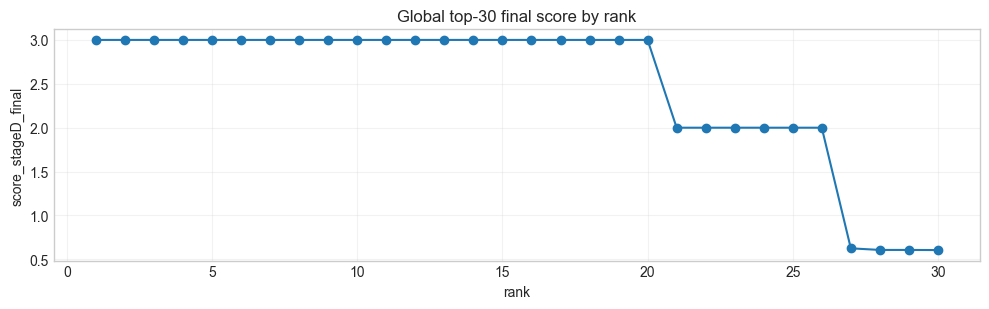

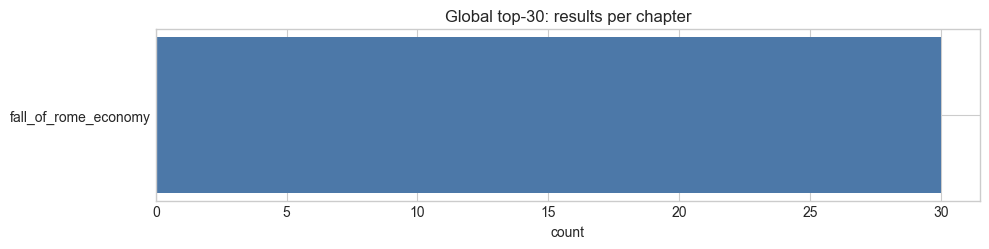

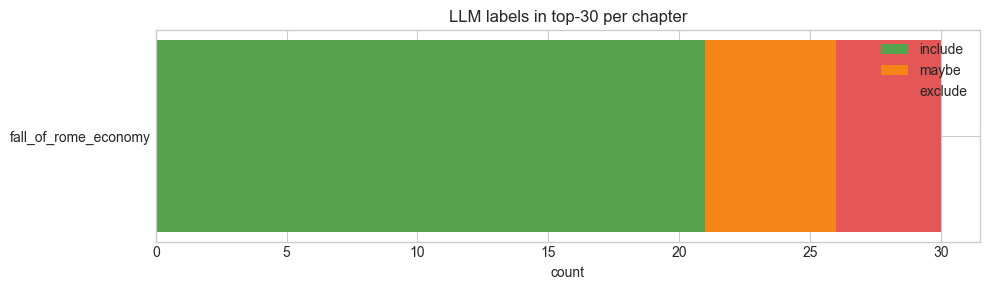

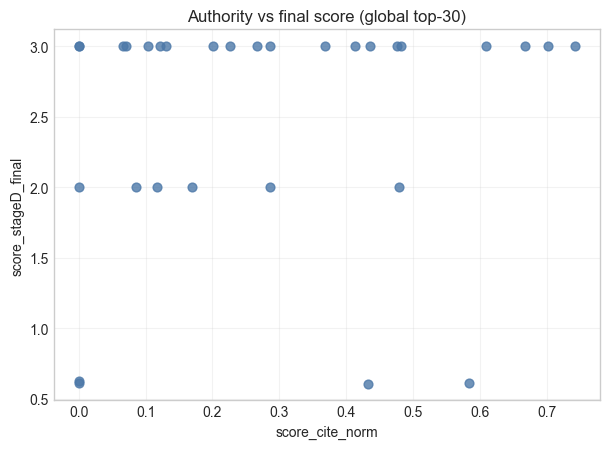


QA summary (top-30):
- fall_of_rome_economy: llm_label counts in top30 = {'include': 21, 'maybe': 5, 'exclude': 4}

=== COPY/PASTE THIS JSON SUMMARY BACK TO CODEX ===
{
  "run_id": "20260208_182359",
  "chapters": [
    "fall_of_rome_economy"
  ],
  "stageB": {
    "variant": "coverage_v1",
    "model": "gpt-5-mini"
  },
  "stageA": {
    "paths": {
      "fall_of_rome_economy": "E:\\Datein\\Coding\\instantpaper\\final_pipeline\\stageA\\fall_of_rome_economy\\cdcc22071541\\stageA_combined.csv"
    }
  },
  "stageC": {
    "weights": {
      "w_embed_max": 0.0,
      "w_embed": 0.7,
      "cite_weight": 0.08
    },
    "embed_totals": {
      "requests": 0,
      "input_tokens": 0,
      "cost_usd": 0.0
    }
  },
  "stageC3": {
    "topn": 50,
    "model": "gpt-5-nano",
    "totals": {
      "seconds": 0.32327938079833984,
      "requests": 0,
      "input_tokens": 0,
      "cached_input_tokens": 0,
      "output_tokens": 0,
      "cost_usd": 0.0,
      "cached_files": 75,
      "topn_

In [16]:

# -----------------------------
# Final run: Stage C.3 + Stage D + exports
# -----------------------------

import json
from pathlib import Path

import pandas as pd

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover
    def display(x):  # type: ignore
        print(x)


def _latest(path_glob):
    cands = sorted(path_glob, key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0] if cands else None


# Load Stage C pool if needed
if "stageC_all" not in globals() or not isinstance(stageC_all, pd.DataFrame) or stageC_all.empty:
    p = _latest(list(STAGEC_DIR.glob("*_stageC_all_pool_scored.csv")))
    if p is None:
        raise FileNotFoundError("No Stage C combined CSV found under final_pipeline/stageC/. Run the Stage C cell first.")
    stageC_all = pd.read_csv(p)
    print("Loaded Stage C combined:", p, "| rows=", len(stageC_all))
else:
    print("Using in-memory stageC_all | rows=", len(stageC_all))


# Stage C.3 (API calls; cached to disk)
stageC3_df, stageC3_totals = await stagec3_rerank_topn(
    stageC_all,
    blueprints_by_chapter_id=blueprints,
    min_non_exclude=int(STAGED_K_SELECT),
)


# Stage D (offline)
final_score_col = "score_stageC3_topn_final"
if STAGED_ENABLED:
    stageC3_df = add_stagec3_signal_v1(stageC3_df)
    stageC3_df = add_stageD_mmr_tfidf_v2(stageC3_df)
    final_score_col = "score_stageD_final"


# Save full scored output
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
full_scored_csv = RESULTS_DIR / f"{RUN_ID}_full_scored.csv"
stageC3_df.to_csv(full_scored_csv, index=False, encoding="utf-8")
print("Saved full scored CSV:", full_scored_csv)

print_section("OpenAI cost summary")
parts = []
total_cost = 0.0
for name, d in [("stageB_blueprints", globals().get("bp_totals")), ("embeddings", globals().get("embed_totals")), ("stageC3_rerank", globals().get("stageC3_totals"))]:
    if isinstance(d, dict):
        c = float(d.get("cost_usd", 0.0) or 0.0)
        total_cost += c
        parts.append({"stage": name, "requests": _fmt_int(d.get("requests", "")), "in_tok": _fmt_int(d.get("input_tokens", "")), "cached_in": _fmt_int(d.get("cached_input_tokens", "")), "out_tok": _fmt_int(d.get("output_tokens", "")), "cost_usd": _fmt_usd(c)})
if parts:
    print_table(parts, columns=["stage","requests","in_tok","cached_in","out_tok","cost_usd"], max_rows=20)
print("Total OpenAI cost (estimated):", _fmt_usd(total_cost))


# -----------------------------
# Query attribution (which retrieval queries produced the winners)
# -----------------------------
PRINT_QUERY_ATTRIBUTION = True
QUERY_ATTRIBUTION_MAX_ROWS = 120


def _split_queries_field(x: object) -> list[str]:
    s = '' if x is None else str(x)
    parts = [p.strip() for p in s.split(';')]
    parts = [p for p in parts if p]
    # dedupe (case-insensitive), preserve order
    out: list[str] = []
    seen: set[str] = set()
    for q in parts:
        k = q.lower()
        if k in seen:
            continue
        seen.add(k)
        out.append(q)
    return out


def _add_query_attribution_cols(df_in: pd.DataFrame, *, base_queries: list[str], extra_queries: list[str]) -> pd.DataFrame:
    df = df_in.copy()
    if 'queries' not in df.columns:
        df['queries'] = ''

    base_set = set([str(q).strip() for q in (base_queries or []) if str(q).strip()])
    extra_set = set([str(q).strip() for q in (extra_queries or []) if str(q).strip()])

    q_lists = df['queries'].fillna('').astype(str).map(_split_queries_field)
    df['query_hit_count'] = q_lists.map(lambda xs: int(len(xs)))

    def n_hits(xs, s):
        return int(sum(1 for q in xs if q in s))

    df['query_hits_base'] = q_lists.map(lambda xs: n_hits(xs, base_set))
    df['query_hits_extra'] = q_lists.map(lambda xs: n_hits(xs, extra_set))
    df['query_hits_unknown'] = q_lists.map(lambda xs: int(sum(1 for q in xs if (q not in base_set and q not in extra_set))))

    def origin(row) -> str:
        b = int(row.get('query_hits_base', 0) or 0)
        e = int(row.get('query_hits_extra', 0) or 0)
        t = int(row.get('query_hit_count', 0) or 0)
        if b > 0 and e > 0:
            return 'both'
        if b > 0:
            return 'base'
        if e > 0:
            return 'extra'
        if t > 0:
            return 'unknown'
        return 'missing'

    df['query_origin'] = df.apply(origin, axis=1)
    return df


def _query_productivity_rows(top_df: pd.DataFrame, *, base_queries: list[str], extra_queries: list[str]) -> list[dict]:
    if 'queries' not in top_df.columns or len(top_df) == 0:
        return []

    q_sets = [set(_split_queries_field(x)) for x in top_df['queries'].fillna('').astype(str).tolist()]

    def count_hit(q: str) -> int:
        q = str(q).strip()
        if not q:
            return 0
        return int(sum(1 for s in q_sets if q in s))

    rows: list[dict] = []
    for kind, qlist in [('base', base_queries or []), ('extra', extra_queries or [])]:
        for q in qlist:
            c = count_hit(q)
            rows.append({
                'kind': kind,
                'count': int(c),
                'share': (float(c) / float(len(top_df))) if len(top_df) else 0.0,
                'query': str(q),
            })

    # unknown queries (present in top results but not in base/extra lists)
    known = set([str(q).strip() for q in (base_queries or []) + (extra_queries or []) if str(q).strip()])
    unknown_counts: dict[str, int] = {}
    for s in q_sets:
        for q in s:
            if q in known:
                continue
            unknown_counts[q] = unknown_counts.get(q, 0) + 1
    for q, c in sorted(unknown_counts.items(), key=lambda kv: (-kv[1], kv[0])):
        rows.append({'kind': 'unknown', 'count': int(c), 'share': (float(c)/float(len(top_df))) if len(top_df) else 0.0, 'query': str(q)})

    rows.sort(key=lambda r: (-int(r.get('count', 0)), str(r.get('kind', '')), str(r.get('query', ''))))
    return rows


# Save per-chapter top30
top30_paths = {}
cols_show = [
    "chapter_id",
    "title",
    "year",
    "venue",
    "doi_norm",
    "sources",
    "queries",
    "query_origin",
    "query_hit_count",
    "query_hits_base",
    "query_hits_extra",
    "score_stageC_final",
    "score_llm_rerank_v1",
    "llm_label",
    "llm_confidence",
    "llm_notes",
    final_score_col,
    "merge_key",
]

for cid, g in stageC3_df.groupby("chapter_id"):
    out_csv = RESULTS_DIR / f"{RUN_ID}_{cid}_top30.csv"
    top = g.sort_values(final_score_col, ascending=False, kind="mergesort").copy()
    if "llm_label" in top.columns:
        top = top[~top["llm_label"].fillna("").astype(str).eq("exclude")].copy()
    top = top.head(30).copy()

    # Query attribution: which Stage A queries retrieved these items?
    try:
        bp = blueprints.get(cid) if isinstance(blueprints, dict) else blueprints[cid]
    except Exception:
        bp = None

    try:
        base_queries = query_list_for_chapter(bp) if bp is not None else []
        extra_queries = expanded_query_list_for_chapter(bp) if bp is not None else []
    except Exception:
        base_queries = []
        if bp is not None:
            base_queries = [getattr(bp, 'main_query', '')] + list(getattr(bp, 'facet_queries', []) or [])
        extra_queries = []

    top = _add_query_attribution_cols(top, base_queries=base_queries, extra_queries=extra_queries)
    keep = [c for c in cols_show if c in top.columns]
    top[keep].to_csv(out_csv, index=False, encoding="utf-8")
    top30_paths[str(cid)] = str(out_csv)
    print(f"[{cid}] saved top30: {out_csv}")
    display(top[keep].head(10))


    if bool(PRINT_QUERY_ATTRIBUTION):
        print_section(f"Query attribution [{cid}] (top-30)")

        # Origin quota: base vs extra vs both
        try:
            vc = top.get('query_origin', pd.Series([], dtype=str)).fillna('missing').astype(str).value_counts().to_dict()
            rows_o = []
            for k, v in vc.items():
                rows_o.append({'origin': k, 'count': int(v), 'share': f"{100.0*float(v)/float(len(top) or 1):.1f}%"})
            print("Origin quota:")
            print_table(rows_o, columns=['origin','count','share'], max_rows=20)
        except Exception:
            pass

        # Productivity per query
        rows_q = _query_productivity_rows(top, base_queries=base_queries, extra_queries=extra_queries)
        if rows_q:
            out_q_csv = RESULTS_DIR / f"{RUN_ID}_{cid}_query_productivity_top30.csv"
            try:
                pd.DataFrame(rows_q).to_csv(out_q_csv, index=False, encoding="utf-8")
                print("Saved query productivity CSV:", out_q_csv)
            except Exception:
                pass
        if rows_q:
            print("\nQuery productivity (top-30):")
            rows_q2 = [
                {**r, 'count': _fmt_int(r.get('count', 0)), 'share': _fmt_pct(r.get('share', 0.0))}
                for r in rows_q
            ]
            print_table(rows_q2, columns=['kind','count','share','query'], max_rows=int(QUERY_ATTRIBUTION_MAX_ROWS))


# Save global top30 across all chapters
global_top30_csv = RESULTS_DIR / f"{RUN_ID}_top30_all_chapters.csv"
gall = stageC3_df.sort_values(final_score_col, ascending=False, kind="mergesort").copy()
if "llm_label" in gall.columns:
    gall = gall[~gall["llm_label"].fillna("").astype(str).eq("exclude")].copy()
g30 = gall.head(30).copy()
keep_global = [c for c in cols_show if c in g30.columns]
g30[keep_global].to_csv(global_top30_csv, index=False, encoding="utf-8")
print("\nSaved global top30:", global_top30_csv)
display(g30[keep_global].head(30))

# Final plots (debug)
print_section("Plots")
plt = get_plt()
if plt and bool(PLOTS_ENABLED):
    try:
        import numpy as np

        # Global top-30 final score by rank
        if 'g30' in globals() and isinstance(g30, pd.DataFrame) and (final_score_col in g30.columns):
            s = pd.to_numeric(g30[final_score_col], errors='coerce').fillna(0.0).to_numpy(dtype=float)
            fig, ax = plt.subplots(1, 1, figsize=(10, 3.2))
            ax.plot(range(1, len(s) + 1), s, marker='o', linewidth=1.5)
            ax.set_title('Global top-30 final score by rank')
            ax.set_xlabel('rank')
            ax.set_ylabel(final_score_col)
            ax.grid(True, alpha=0.25)
            plt.tight_layout()
            plt.show()

        # Chapter composition in global top-30
        if 'g30' in globals() and isinstance(g30, pd.DataFrame) and ('chapter_id' in g30.columns):
            vc = g30['chapter_id'].fillna('').astype(str).value_counts()
            if len(vc):
                fig, ax = plt.subplots(1, 1, figsize=(10, max(2.6, 0.5 * len(vc) + 1.2)))
                ax.barh([short_label(x, 34) for x in vc.index.tolist()], vc.values.tolist(), color='#4C78A8')
                ax.set_title('Global top-30: results per chapter')
                ax.set_xlabel('count')
                plt.tight_layout()
                plt.show()

        # LLM label composition in per-chapter top-30
        if ('llm_label' in stageC3_df.columns) and ('chapter_id' in stageC3_df.columns):
            top_by_ch = stageC3_df.sort_values(final_score_col, ascending=False, kind='mergesort').groupby('chapter_id').head(30).copy()
            top_by_ch['_llm_label'] = top_by_ch['llm_label'].fillna('').astype(str)
            top_by_ch.loc[top_by_ch['_llm_label'].eq(''), '_llm_label'] = '(blank)'

            counts = top_by_ch.pivot_table(index='chapter_id', columns='_llm_label', values=final_score_col, aggfunc='size', fill_value=0)
            col_order = ['include', 'maybe', 'exclude', '(blank)']
            cols = [c for c in col_order if c in counts.columns] + [c for c in counts.columns if c not in col_order]
            counts = counts[cols]

            fig, ax = plt.subplots(1, 1, figsize=(10, max(3.0, 0.55 * len(counts) + 1.6)))
            left = np.zeros(len(counts), dtype=float)
            colors = {'include': '#54A24B', 'maybe': '#F58518', 'exclude': '#E45756', '(blank)': '#B8B0AC'}
            ylabels = [short_label(x, 34) for x in counts.index.tolist()]

            for col in cols:
                vals = counts[col].to_numpy(dtype=float)
                ax.barh(ylabels, vals, left=left, label=col, color=colors.get(col))
                left = left + vals

            ax.set_title('LLM labels in top-30 per chapter')
            ax.set_xlabel('count')
            ax.legend(loc='best')
            plt.tight_layout()
            plt.show()

        # Authority vs final score in global top-30
        if 'g30' in globals() and isinstance(g30, pd.DataFrame) and ('score_cite_norm' in g30.columns) and (final_score_col in g30.columns):
            x = pd.to_numeric(g30['score_cite_norm'], errors='coerce').fillna(0.0)
            y = pd.to_numeric(g30[final_score_col], errors='coerce').fillna(0.0)
            fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.6))
            ax.scatter(x, y, s=40, alpha=0.8, color='#4C78A8')
            ax.set_title('Authority vs final score (global top-30)')
            ax.set_xlabel('score_cite_norm')
            ax.set_ylabel(final_score_col)
            ax.grid(True, alpha=0.25)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print('[plots] Final plots skipped:', e)


# Build a concise run summary for copy/paste
stagea_paths = {}
for ch in CHAPTERS:
    cid = ch["chapter_id"]
    bp = blueprints[cid]
    # Recompute the Stage A signature (must match Stage A cell logic)
    try:
        base_queries = query_list_for_chapter(bp)
        extra_queries = expanded_query_list_for_chapter(bp)
        queries_all = dedupe_preserve_order(list(base_queries) + list(extra_queries))
        concept_terms = openalex_concept_terms_for_chapter(bp)
    except Exception:
        base_queries = [bp.main_query] + list(bp.facet_queries or [])
        extra_queries = []
        queries_all = base_queries
        concept_terms = []

    sig_obj = {
        "base_queries": base_queries,
        "extra_queries": extra_queries,
        "queries_all": queries_all,
        "OA_MAX_WORKS_PER_QUERY": globals().get("OA_MAX_WORKS_PER_QUERY"),
        "OA_MAX_WORKS_PER_QUERY_EXTRA": globals().get("OA_MAX_WORKS_PER_QUERY_EXTRA"),
        "OA_AUTHORITY_PULL_ENABLED": globals().get("OA_AUTHORITY_PULL_ENABLED"),
        "OA_AUTHORITY_PULL_MAX_WORKS": globals().get("OA_AUTHORITY_PULL_MAX_WORKS"),
        "OA_AUTHORITY_PULL_SORT": globals().get("OA_AUTHORITY_PULL_SORT"),
        "OA_CONCEPT_FILTER_ENABLED": globals().get("OA_CONCEPT_FILTER_ENABLED"),
        "OA_CONCEPT_FILTER_FOR_EXTRA_QUERIES": globals().get("OA_CONCEPT_FILTER_FOR_EXTRA_QUERIES"),
        "OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL": globals().get("OA_CONCEPT_FILTER_FOR_AUTHORITY_PULL"),
        "OA_CONCEPT_TERMS": concept_terms,
        "OA_CONCEPT_MAX_IDS": globals().get("OA_CONCEPT_MAX_IDS"),
        "S2_LIMIT": globals().get("S2_LIMIT"),
        "S2_MAX_PAGES_PER_QUERY": globals().get("S2_MAX_PAGES_PER_QUERY"),
    }
    sig = hashlib.sha1(json.dumps(sig_obj, sort_keys=True, ensure_ascii=False).encode("utf-8")).hexdigest()[:12]
    stagea_paths[cid] = str((STAGEA_DIR / cid / sig / "stageA_combined.csv").resolve())

summary = {
    "run_id": RUN_ID,
    "chapters": [c["chapter_id"] for c in CHAPTERS],
    "stageB": {"variant": STAGEB_FINAL_VARIANT, "model": BLUEPRINT_MODEL},
    "stageA": {"paths": stagea_paths},
    "stageC": {
        "weights": {
            "w_embed_max": STAGEC_W_EMBED_MAX,
            "w_embed": STAGEC_W_EMBED,
            "cite_weight": STAGEC_CITE_WEIGHT,
        },
        "embed_totals": globals().get("embed_totals", {}),
    },
    "stageC3": {"topn": STAGEC3_TOPN, "model": STAGEC3_MODEL, "totals": stageC3_totals},
    "stageD": {"enabled": STAGED_ENABLED, "topm": STAGED_TOPM, "k_select": STAGED_K_SELECT, "lambda": STAGED_LAMBDA},
    "outputs": {
        "full_scored_csv": str(full_scored_csv),
        "top30_csvs": top30_paths,
        "global_top30_csv": str(globals().get("global_top30_csv", "")),
        "final_score_col": final_score_col,
    },
}

summary_path = RESULTS_DIR / f"{RUN_ID}_run_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")


# -----------------------------
# QA summary (sanity checks)
# -----------------------------
print('\nQA summary (top-30):')
for cid, g in stageC3_df.groupby('chapter_id'):
    top = g.sort_values(final_score_col, ascending=False, kind='mergesort').head(30)
    if 'llm_label' in top.columns:
        counts = top['llm_label'].fillna('').astype(str).value_counts().to_dict()
        print(f'- {cid}: llm_label counts in top30 = {counts}')
        if counts.get('exclude', 0) > 0:
            print(f'  WARNING: excludes present in top30 for {cid}')
        if counts.get('', 0) > 0:
            print(f'  WARNING: blank llm_label present in top30 for {cid} (likely unscored tail)')

print("\n=== COPY/PASTE THIS JSON SUMMARY BACK TO CODEX ===")
print(json.dumps(summary, ensure_ascii=False, indent=2))
print("\nSaved summary file:", summary_path)
